# Exploratory data analysis: Adult census income dataset

**ML-MDS 2026 - Elisa Müller and Berta Torrents**

## 0. Introduction and dataset context

This notebook presents a thorough exploratory analysis of the **Adult census income** dataset, originally extracted by Barry Becker from the 1994 US Census Bureau database. The dataset is publicly available through the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult).

**Prediction task:** binary classification problem that determines whether an individual earns more than $50,000 per year.

**Historical context:** in 1994, a $50K annual income placed an individual roughly in the top 25% of US earners. The socioeconomic patterns in this dataset, such as gender gaps, occupational distributions, and educational attainment rates, reflect the mid-1990s expansion that followed the early-90s recession in the United States.

**Important note on identifiers:** this dataset has no individual ID column. Each row represents a census record, but there is no guaranteed one-to-one mapping between rows and unique individuals. The duplicate analysis in Section 4 addresses this directly.

This notebook covers the full exploratory analysis of the dataset, organized as follows. Section 1 handles setup and data loading. Section 2 provides a general overview of the dataset and examines each feature individually through univariate analysis. Section 3 through 5 assess data quality: missing values, duplicates, and outliers or invalid encoded values. Section 6 analyzes the target variable and measures how strongly each feature associates with income using point-biserial correlation and Cramér's V, including interaction effects. Section 7 studies feature relationships and redundancy. Section 8 summarizes all findings and the corresponding preprocessing decisions.

## 1. Setup and data loading

In [81]:
%pip install numpy pandas matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# Helper functions

def cramers_v(x, y):
    """Cramér's V association measure between two categorical variables."""
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    if n == 0 or min_dim == 0:
        return np.nan
    return np.sqrt(chi2 / (n * min_dim))


def annotate_bars(ax, fmt="{:.0f}", fontsize=9):
    """Add value labels on top of each bar in a bar chart."""
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            fmt.format(bar.get_height()),
            ha="center", va="bottom", fontsize=fontsize,
        )


def plot_numerical(df, columns, bins=50, figsize=None):
    """Histogram for each numerical column."""
    n = len(columns)
    nrows = (n + 2) // 3
    if figsize is None:
        figsize = (15, 4 * nrows)
    fig, axes = plt.subplots(nrows, 3, figsize=figsize)
    axes = axes.flatten()
    for ax, col in zip(axes, columns):
        ax.hist(df[col].dropna(), bins=bins, color="steelblue", edgecolor="white")
        ax.set_title(col)
        ax.set_ylabel("Frequency")
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_categorical(df, columns, figsize=None):
    """Proportion bar chart for each categorical column."""
    n = len(columns)
    nrows = (n + 2) // 3
    if figsize is None:
        figsize = (15, 4 * nrows)
    fig, axes = plt.subplots(nrows, 3, figsize=figsize)
    axes = axes.flatten()
    for ax, col in zip(axes, columns):
        proportions = df[col].value_counts(normalize=True, dropna=False).sort_values(ascending=False)
        proportions.plot(kind="bar", ax=ax, color="steelblue")
        ax.set_title(col)
        ax.set_ylabel("Proportion")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def summarize_numerical(df, columns):
    """Descriptive statistics for numerical columns."""
    desc = df[columns].describe().T
    desc["n_zeros"] = (df[columns] == 0).sum()
    desc["pct_zeros"] = (desc["n_zeros"] / len(df) * 100).round(2)
    print(desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "n_zeros", "pct_zeros"]].round(2))


def summarize_categorical(df, columns):
    """Value counts and proportion for categorical columns."""
    for col in columns:
        counts = df[col].value_counts(dropna=False)
        proportions = (counts / len(df) * 100).round(2)
        summary = pd.DataFrame({"count": counts, "pct": proportions})
        print(f"  {col} ({df[col].nunique(dropna=False)} unique, {df[col].isnull().sum()} missing)")
        print(summary.to_string())

In [83]:
DATA_PATH = "adult.csv"
TARGET = "income"

df = pd.read_csv(DATA_PATH, na_values="?")

# Clean column names: strip whitespace, replace dots with underscores.
df.columns = df.columns.str.strip().str.replace(".", "_", regex=False)

# Strip leading/trailing whitespace from all string columns.
str_cols = df.select_dtypes(include=["object", "string"]).columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

NUM_COLS = df.select_dtypes(include="number").columns.tolist()
CAT_COLS = [c for c in df.select_dtypes(include=["object", "string"]).columns if c != TARGET]

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNumerical features ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical features ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Target: {TARGET}")

Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Numerical features (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Target: income


## 2. Dataset overview and univariate analysis

This section provides a general overview of the dataset structure and examines each feature individually. The goal is to understand the shape of each variable, identify distributional characteristics (skewness, zero-inflation, rare categories), and flag potential issues before moving to data quality analysis.

### 2.1 General overview

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [85]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000,32561.000,32561.000,32561.000,32561.000,32561.000
mean,38.582,189778.367,10.081,1077.649,87.304,40.437
std,13.640,105549.978,2.573,7385.292,402.960,12.347
min,17.000,12285.000,1.000,0.000,0.000,1.000
25%,28.000,117827.000,9.000,0.000,0.000,40.000
50%,37.000,178356.000,10.000,0.000,0.000,40.000
75%,48.000,237051.000,12.000,0.000,0.000,45.000
max,90.000,1484705.000,16.000,99999.000,4356.000,99.000


In [86]:
df.describe(include=['object', 'string'])

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


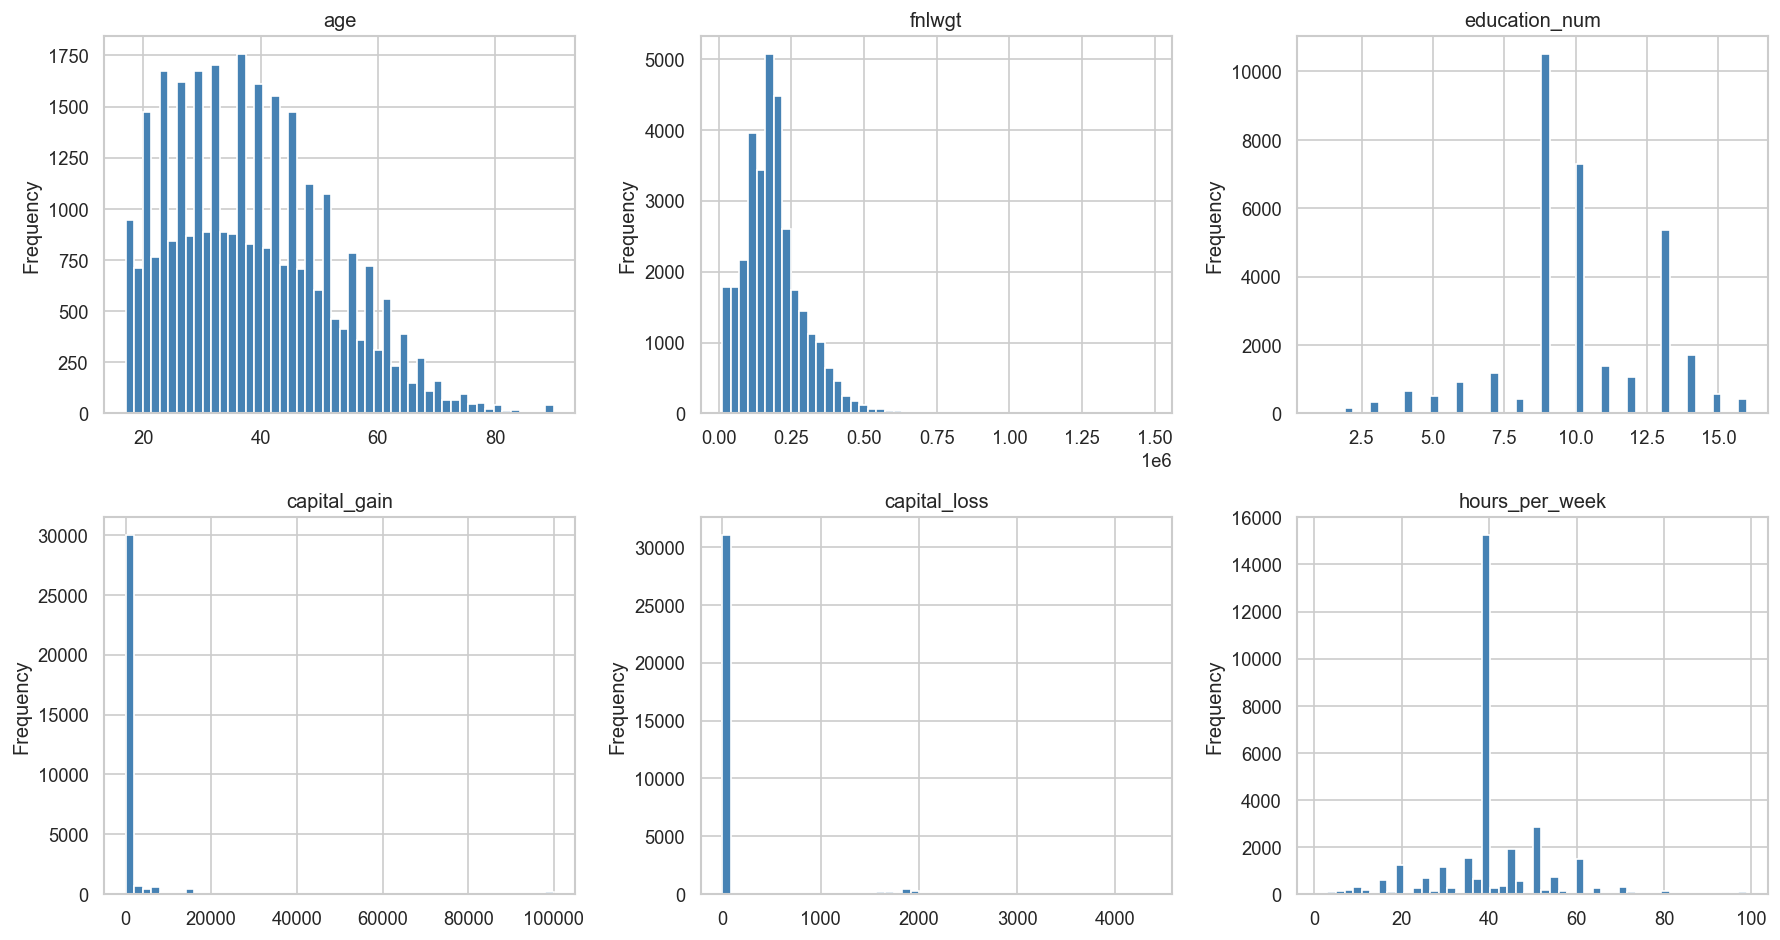

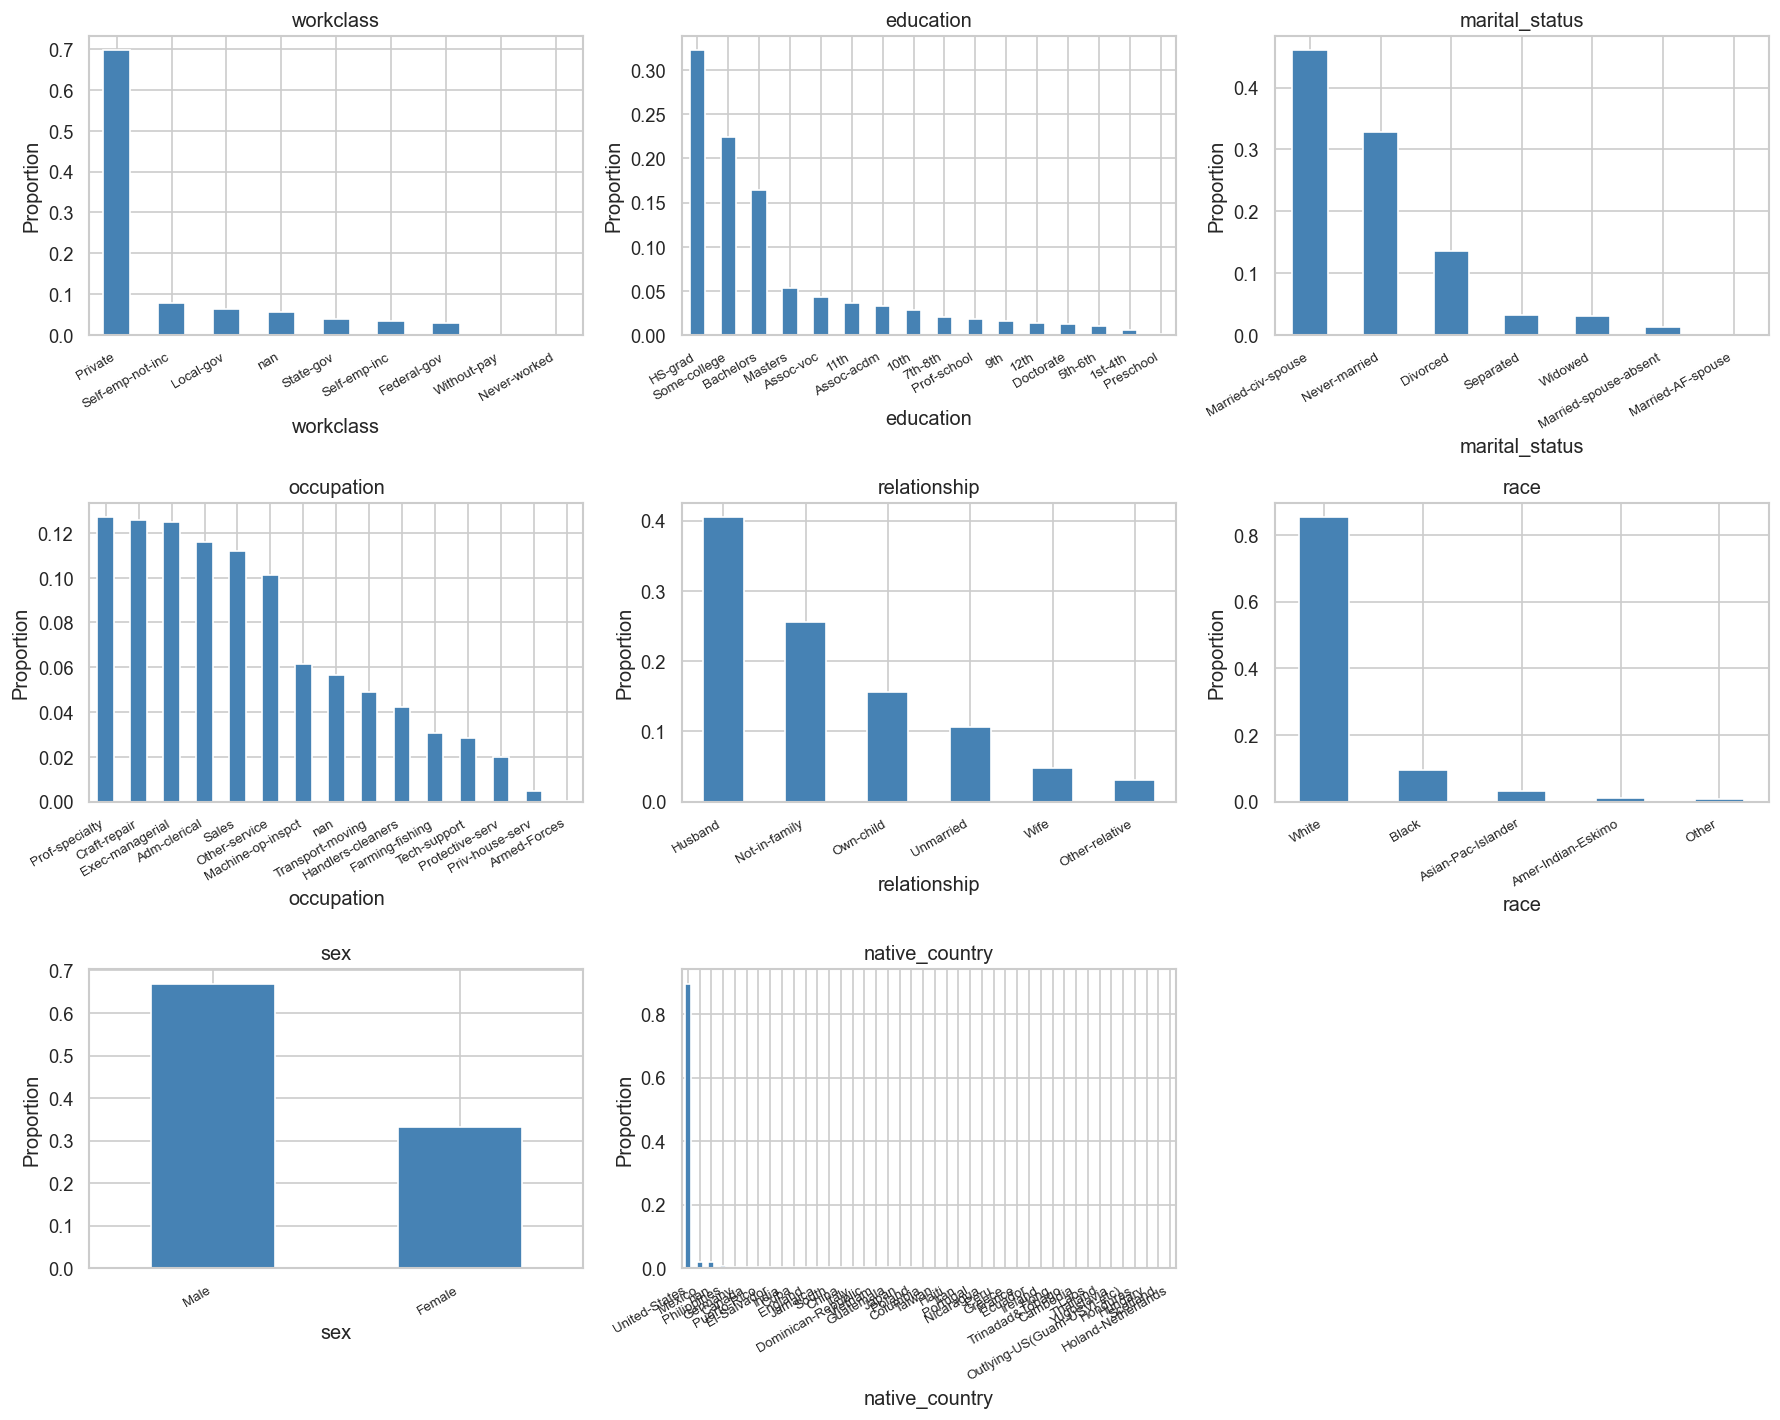

In [87]:
plot_numerical(df, NUM_COLS)
plot_categorical(df, CAT_COLS)

In [88]:
summarize_numerical(df, NUM_COLS)
summarize_categorical(df, CAT_COLS)

                   count       mean        std       min        25%  \
age            32561.000     38.580     13.640    17.000     28.000   
fnlwgt         32561.000 189778.370 105549.980 12285.000 117827.000   
education_num  32561.000     10.080      2.570     1.000      9.000   
capital_gain   32561.000   1077.650   7385.290     0.000      0.000   
capital_loss   32561.000     87.300    402.960     0.000      0.000   
hours_per_week 32561.000     40.440     12.350     1.000     40.000   

                      50%        75%         max  n_zeros  pct_zeros  
age                37.000     48.000      90.000        0      0.000  
fnlwgt         178356.000 237051.000 1484705.000        0      0.000  
education_num      10.000     12.000      16.000        0      0.000  
capital_gain        0.000      0.000   99999.000    29849     91.670  
capital_loss        0.000      0.000    4356.000    31042     95.330  
hours_per_week     40.000     45.000      99.000        0      0.000  
  wor

The dataset contains 32,561 observations and 15 columns (14 features and 1 binary target). Six features are numerical and eight are categorical. The target variable `income` takes two values: `<=50K` and `>50K`.

A first inspection reveals three columns with missing values: `workclass` (1,836 null entries, 5.64%), `occupation` (1,843, 5.66%), and `native_country` (583, 1.79%). All numerical columns are complete. The following subsections examine each feature in detail.

In [89]:
desc = df[NUM_COLS].describe().T
desc["skewness"] = df[NUM_COLS].skew()
print(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skewness"]].round(2))

                     mean        std       min        25%        50%  \
age                38.580     13.640    17.000     28.000     37.000   
fnlwgt         189778.370 105549.980 12285.000 117827.000 178356.000   
education_num      10.080      2.570     1.000      9.000     10.000   
capital_gain     1077.650   7385.290     0.000      0.000      0.000   
capital_loss       87.300    402.960     0.000      0.000      0.000   
hours_per_week     40.440     12.350     1.000     40.000     40.000   

                      75%         max  skewness  
age                48.000      90.000     0.560  
fnlwgt         237051.000 1484705.000     1.450  
education_num      12.000      16.000    -0.310  
capital_gain        0.000   99999.000    11.950  
capital_loss        0.000    4356.000     4.590  
hours_per_week     45.000      99.000     0.230  


### 2.2 Numerical features

**Numerical features:**

- **`age`**: the age of the individual in years. It ranges from 17 to 90 with a mean of 38.6 and a roughly symmetric distribution (skewness 0.56). The minimum of 17 is consistent with the extraction condition of age > 16.
- **`fnlwgt`**: the final sampling weight assigned by the Census Bureau, representing how many people in the general population each record is estimated to represent. It has a wide range (12,285 to 1,484,705) and high variability, but it is a property of the survey design, not of the individual. Its relevance as a predictive feature will be discussed in later sections.
- **`education_num`**: an ordinal encoding of the highest level of education attained, ranging from 1 (Preschool) to 16 (Doctorate). It is slightly left-skewed (−0.31), with the median at 10 (corresponding to some college education).
- **`capital_gain`**: the capital gains recorded for the individual in the tax year. It is zero in 91.67% of the rows, with extreme right skewness (11.95). The maximum value is 99,999, a suspiciously round number that will be investigated in the outlier analysis section.
- **`capital_loss`**: the capital losses recorded for the individual in the tax year. Similarly zero-inflated (95.33% zeros), with high skewness (4.59). The maximum is 4,356.
- **`hours_per_week`**: the number of hours the individual typically works per week. It ranges from 1 to 99, with a sharp peak at 40 reflecting the standard full-time work week. The mean (40.44) and median (40) are nearly identical.

### 2.3 Categorical features

**Categorical features:**

- **`workclass`**: the type of employer or employment status of the individual. It has 9 unique values with 1,836 missing entries. Dominated by `Private` (69.70%). Government positions (`Local-gov`, `State-gov`, `Federal-gov`) together account for 13.37%, and self-employed categories for 11.23%. `Without-pay` (14 rows) and `Never-worked` (7 rows) are extremely rare.
- **`education`**: the highest level of education attained, expressed as a categorical label. It has 16 unique values with no missing entries. The most common levels are `HS-grad` (32.25%) and `Some-college` (22.39%). Advanced degrees (`Masters`, `Doctorate`, `Prof-school`) together account for 8.33%, while early education levels (`1st-4th`, `Preschool`) are very rare.
- **`marital_status`**: the marital status of the individual. It has 7 unique values, led by `Married-civ-spouse` (45.99%) and `Never-married` (32.81%). `Married-AF-spouse` (Armed Forces spouse) has only 23 observations.
- **`occupation`**: the type of work performed by the individual. It has 15 unique values with 1,843 missing entries. More evenly distributed than other categorical features, with the top four categories (`Prof-specialty`, `Craft-repair`, `Exec-managerial`, `Adm-clerical`) each around 11–13%. `Armed-Forces` (9 rows) and `Priv-house-serv` (149 rows) are very rare.
- **`relationship`**: the individual's role within the household relative to the head of household. It has 6 unique values, with `Husband` (40.52%) and `Not-in-family` (25.51%) being the most common. This variable encodes a combination of marital status, sex, and household position.
- **`race`**: the self-reported race of the individual. It has 5 unique values, heavily skewed toward `White` (85.43%). `Black` accounts for 9.59%, while the remaining three categories together represent less than 5%.
- **`sex`**: the biological sex of the individual. Binary, with `Male` (66.92%) outnumbering `Female` (33.08%) by approximately two to one.
- **`native_country`**: the country of origin of the individual. It has 42 unique values with 583 missing entries, dominated by `United-States` (89.59%). Only `Mexico` (1.97%) exceeds 1% among the remaining countries, and many have fewer than 50 observations, which will require grouping rare categories in preprocessing.

The most frequent target class is `<=50K` with 24,720 observations, indicating a class imbalance that will be examined in Section 6.

### 2.4 Feature-specific analyses

#### Relation between `education` and `education_num`

A quick inspection of the dataset's variables suggests that `education` and `education_num` features may be encoding the exact same information under different formats.

In [90]:
import pandas as pd

# Group by the number and see how many unique text descriptions each number has
num_map = df.groupby("education_num")["education"].agg(["nunique", "count"])

print("Education Num to Education Mapping")
print(num_map)

# Definitive test for your question
all_nums_have_unique_edu = (num_map['nunique'] == 1).all()

print(f"Do all people with the same education_num have the exact same education text? {all_nums_have_unique_edu}")

if not all_nums_have_unique_edu:
    print("\n Some education_numbers map to multiple text descriptions.")
    # Show the overlaps if they exist
    overlap = df.groupby("education_num")["education"].unique()
    print(overlap[overlap.str.len() > 1])
else:
    print("\nEvery education_num belongs to one, and only one, education level.")
    
    # Print the clean mapping dictionary for you to see
    clean_map = df[["education_num", "education"]].drop_duplicates().sort_values("education_num")
    print(clean_map.to_string(index=False))

Education Num to Education Mapping
               nunique  count
education_num                
1                    1     51
2                    1    168
3                    1    333
4                    1    646
5                    1    514
6                    1    933
7                    1   1175
8                    1    433
9                    1  10501
10                   1   7291
11                   1   1382
12                   1   1067
13                   1   5355
14                   1   1723
15                   1    576
16                   1    413
Do all people with the same education_num have the exact same education text? True

Every education_num belongs to one, and only one, education level.
 education_num    education
             1    Preschool
             2      1st-4th
             3      5th-6th
             4      7th-8th
             5          9th
             6         10th
             7         11th
             8         12th
             9      HS

Each `education` string maps to exactly one `education_num` value, and every `education_num` maps to exactly one `education` text label. Because they are perfectly redundant, they should not be used together. Depending on the model, one form will be more appropriate than the other.

#### Relation between `relationship`, `marital_status`, `sex`

Taking into account the nature of these variables, there is an inherent conceptual overlap between household roles, marital status, and sex. To determine if the relationship feature simply repeats or combines the information already contained in the other two variables, a cross-tabulation and top-combination analysis were performed.

In [91]:
# Cross-tabulation to see how relationship encodes marital_status + sex
ct = pd.crosstab(df["relationship"], [df["marital_status"], df["sex"]])
print("Top combinations per relationship category:\n")

for rel in df["relationship"].dropna().unique():
    subset = df[df["relationship"] == rel]
    top = subset.groupby(["marital_status", "sex"]).size().sort_values(ascending=False).head(3)
    print()
    print(f"{rel}")
    print(top)
    print()

Top combinations per relationship category:


Not-in-family
marital_status  sex   
Never-married   Male      2700
                Female    2006
Divorced        Male      1227
dtype: int64


Unmarried
marital_status  sex   
Divorced        Female    1279
Never-married   Female     581
Separated       Female     380
dtype: int64


Own-child
marital_status  sex   
Never-married   Male      2532
                Female    1953
Divorced        Male       177
dtype: int64


Other-relative
marital_status      sex   
Never-married       Male      384
                    Female    227
Married-civ-spouse  Male       71
dtype: int64


Husband
marital_status      sex   
Married-civ-spouse  Male      13183
Married-AF-spouse   Male          9
Married-civ-spouse  Female        1
dtype: int64


Wife
marital_status      sex   
Married-civ-spouse  Female    1554
Married-AF-spouse   Female      12
Married-civ-spouse  Male         2
dtype: int64



The analysis confirms that`relationship` partially encodes a combination of `marital_status` and `sex`. For example, Husband strongly aligns with the Married-civ-spouse and Male combination, while Wife aligns with Married-civ-spouse and Female. This overlap introduces partial information redundancy. However, the redundancy is incomplete because relationship captures unique household dynamics (such as Own-child or Not-in-family) that neither `marital_status` nor `sex` describes independently.

Consequently, all three features will be retained for the initial modeling phase. Regularized models are capable of handling minor redundancies, and tree-based algorithms will inherently select the most informative split. This cross-variable overlap will be kept in mind for downstream model interpretation.

#### Proportion of `native_country` (US dominance)

In [92]:
country_counts = df["native_country"].value_counts(dropna=False)
us_count = country_counts.get("United-States", 0)
print(f"United-States: {us_count} ({us_count / len(df) * 100:.1f}%)")
print(f"All other countries combined: {len(df) - us_count - df['native_country'].isnull().sum()}")
print(f"Missing: {df['native_country'].isnull().sum()}")

print("\nCountries with >= 100 observations:")
large_countries = country_counts[country_counts >= 100]
print(large_countries)

print(f"\nCountries with < 50 observations: {(country_counts < 50).sum()}")

United-States: 29170 (89.6%)
All other countries combined: 2808
Missing: 583

Countries with >= 100 observations:
native_country
United-States    29170
Mexico             643
NaN                583
Philippines        198
Germany            137
Canada             121
Puerto-Rico        114
El-Salvador        106
India              100
Name: count, dtype: int64

Countries with < 50 observations: 20


The `native_country` feature is heavily dominated by the United States, which accounts for roughly 90% of the observations. Most other countries contain fewer than 100 samples, and many have fewer than 50. One-hot encoding this variable directly would introduce approximately 40 sparse columns with mostly zero values. To prevent this issue, countries that fall below a frequency threshold of 1% of the dataset will be grouped into an `"Other"` category during preprocessing.

## 3. Data quality: missing values

Missing values in this dataset are encoded as `"?"` in the original CSV and were loaded as `NaN` via the `na_values="?"` parameter. Three columns are affected: `workclass`, `occupation`, and `native_country`.

In [93]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "percentatge": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("count", ascending=False)
print(missing_df)

rows_with_any_missing = df.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_any_missing} ({rows_with_any_missing / len(df) * 100:.1f}%)")

                count  percentatge
occupation       1843        5.660
workclass        1836        5.640
native_country    583        1.790

Rows with at least one missing value: 2399 (7.4%)


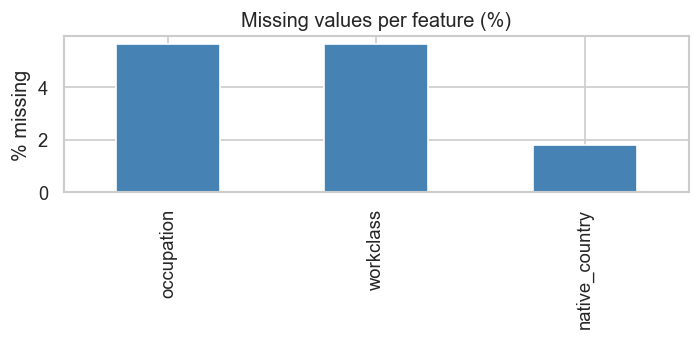

In [94]:
fig, ax = plt.subplots(figsize=(6, 3))
missing_df["percentatge"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Missing values per feature (%)")
ax.set_ylabel("% missing")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Three features contain missing values. `occupation` and `workclass` are the features with higher missigness (5.66% and 5.64%, respectivelly).

`native_country` has a smaller gap of 1.79% missing entries.

In total, 2,399 rows (7.4% of the dataset) have at least one missing value. Whether these missing values are random or structurally caused is examined in the following subsections.

### 3.1 Co-occurrence of missing values

Determining whether missing values occur independently or follow a structured pattern is essential for choosing the right imputation strategy. If missingness is random, simple imputation methods such as mode replacement are appropriate. If instead certain columns tend to be missing together, the missingness is likely structural, meaning it carries information about the underlying data and should be handled accordingly.

The following analysis computes all possible missingness combinations across `workclass`, `occupation`, and `native_country` to distinguish between these cases.

                                pattern  count  percentatge
                             No missing  30162       92.630
                 workclass + occupation   1809        5.560
                         native_country    556        1.710
workclass + occupation + native_country     27        0.080
                             occupation      7        0.020


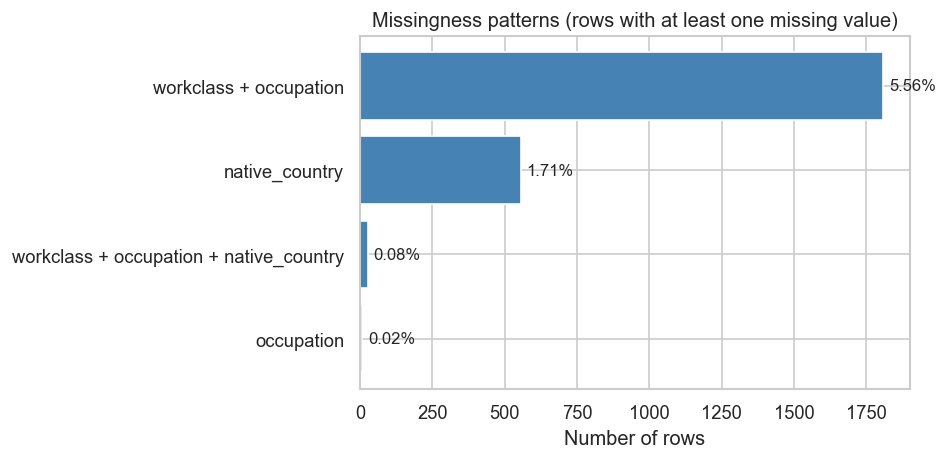

In [95]:
# Co-occurrence of missing values across the three affected columns
missing_flags = pd.DataFrame({
    "workclass": df["workclass"].isnull(),
    "occupation": df["occupation"].isnull(),
    "native_country": df["native_country"].isnull(),
})

# Count every combination of missingness
pattern_counts = (
    missing_flags
    .groupby(["workclass", "occupation", "native_country"])
    .size()
    .reset_index(name="count")
)
pattern_counts["percentatge"] = (pattern_counts["count"] / len(df) * 100).round(2)

# Label each pattern in a readable way
def label_pattern(row):
    missing = [col for col in ["workclass", "occupation", "native_country"] if row[col]]
    return " + ".join(missing) if missing else "No missing"

pattern_counts["pattern"] = pattern_counts.apply(label_pattern, axis=1)
pattern_counts = pattern_counts.sort_values("count", ascending=False)
print(pattern_counts[["pattern", "count", "percentatge"]].to_string(index=False))

# Bar chart of missingness patterns (excluding "No missing" to focus on the interesting ones)
patterns_to_plot = pattern_counts[pattern_counts["pattern"] != "No missing"].copy()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(patterns_to_plot["pattern"], patterns_to_plot["count"], color="steelblue")
for bar, pct in zip(bars, patterns_to_plot["percentatge"]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=10)
ax.set_xlabel("Number of rows")
ax.set_title("Missingness patterns (rows with at least one missing value)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The results confirm that missingness is not random. The dominant pattern is `workclass` and `occupation` missing together (1,809 rows, 5.56%), which strongly suggests a structural cause: these rows likely correspond to individuals outside the labor force (retirees, students, homemakers) for whom employment-related fields are not applicable. Only 7 rows have `occupation` missing alone without `workclass`, reinforcing the idea that the two fields are tied to the same underlying condition. In contrast, `native_country` missingness appears largely independent, with 556 rows (1.71%) missing only that column and just 27 rows where all three columns are missing simultaneously.

This distinction will guide the imputation strategy. For the 1,809 rows where `workclass` and `occupation` are missing together, both columns should be filled with an explicit `"Unknown"` new category rather than mode-imputed, since replacing them with `"Private"` or `"Prof-specialty"` would misrepresent individuals who are likely not employed. The 7 rows where only `occupation` is missing while `workclass` is present represent a different situation: these individuals do have a known employment context, so mode imputation within their `workclass` group is a reasonable approach. For `native_country`, mode imputation is acceptable given the more random nature of its missingness.

### 3.2 Profile of rows with missing `workclass` + `occupation`

The previous section identified 1,809 rows where both employment-related columns are missing simultaneously. To confirm whether this reflects a specific demographic group rather than random data loss, the following analysis compares the profile of these rows against the rest of the dataset in terms of age, education level, income distribution, and household relationship.

In [96]:
mask_both_missing = df["workclass"].isnull() & df["occupation"].isnull()

print(f"Rows with both workclass and occupation missing: {mask_both_missing.sum()}")
print(f"\nAge distribution (missing vs present)")
print(f"Missing group - mean age: {df.loc[mask_both_missing, 'age'].mean():.1f}, median: {df.loc[mask_both_missing, 'age'].median():.0f}")
print(f"Present group - mean age: {df.loc[~mask_both_missing, 'age'].mean():.1f}, median: {df.loc[~mask_both_missing, 'age'].median():.0f}")

print(f"\nEducation level (missing vs present)")
print(f"Missing group - mean education_num: {df.loc[mask_both_missing, 'education_num'].mean():.1f}")
print(f"Present group - mean education_num: {df.loc[~mask_both_missing, 'education_num'].mean():.1f}")

print(f"\nIncome distribution (missing vs present)")
print("Missing group:")
print(df.loc[mask_both_missing, TARGET].value_counts(normalize=True).round(3).to_string())
print("\nPresent group:")
print(df.loc[~mask_both_missing, TARGET].value_counts(normalize=True).round(3).to_string())

print(f"\nRelationship status of missing group")
print(df.loc[mask_both_missing, "relationship"].value_counts())

Rows with both workclass and occupation missing: 1836

Age distribution (missing vs present)
Missing group - mean age: 41.0, median: 35
Present group - mean age: 38.4, median: 37

Education level (missing vs present)
Missing group - mean education_num: 9.3
Present group - mean education_num: 10.1

Income distribution (missing vs present)
Missing group:
income
<=50K   0.896
>50K    0.104

Present group:
income
<=50K   0.751
>50K    0.249

Relationship status of missing group
relationship
Own-child         538
Husband           489
Not-in-family     439
Unmarried         175
Wife              132
Other-relative     63
Name: count, dtype: int64


The profile of the 1,836 rows with both `workclass` and `occupation` missing differs noticeably from the rest of the dataset.

Their mean age is slightly higher (41.0 vs 38.4), but the median is lower (35 vs 37), indicating a bimodal age distribution that likely mixes young individuals not yet in the workforce with older retirees. Their average education level is lower (9.3 vs 10.1, roughly corresponding to a high school diploma without completion). The income distribution is heavily skewed toward `<=50K`, which is consistent with people who are not earning employment income. The relationship status breakdown reinforces this interpretation: the largest group is `Own-child` (538), a census category that identifies individuals recorded as sons or daughters of the head of household, typically young adults who have not yet entered the workforce, followed by `Husband` (489) and `Not-in-family` (439).

Taken together, these patterns confirm that the missingness is informative and likely corresponds to individuals outside the labor force. Hence, the missingness is not random data loss.

### 3.3 Missingness correlation with all features

The previous analysis showed qualitatively that the missing employment rows correspond to a distinct demographic profile. This section quantifies the statistical association between the missingness indicators and every other feature in the dataset, to determine whether preserving them as binary features in the model is justified.

In [97]:
missing_cols = ["workclass", "occupation", "native_country"]

# Create temporary indicators for analysis
for col in missing_cols:
    df[f"is_{col}_NA"] = df[col].isnull().astype(int)

indicator_cols = [f"is_{col}_NA" for col in missing_cols]

# Point-biserial correlations: missing indicators vs numerical features
print("Point-biserial correlations: missing indicators vs numerical features\n")
pb_results = []
for ind in indicator_cols:
    for num_col in NUM_COLS:
        valid = df[[num_col, ind]].dropna()
        r, p = stats.pointbiserialr(valid[ind], valid[num_col])
        pb_results.append({"indicator": ind, "feature": num_col, "r": round(r, 3), "p": round(p, 4)})

pb_df = pd.DataFrame(pb_results)
# Show only statistically significant correlations
sig = pb_df[pb_df["p"] < 0.05].sort_values("r", key=abs, ascending=False)
print(sig.to_string(index=False))

# Cramér's V: missing indicators vs target
print("\nCramér's V: missing indicators vs target")
for ind in indicator_cols:
    cv = cramers_v(df[ind], df[TARGET])
    print(f"  {ind} vs {TARGET}: V = {cv:.3f}")

Point-biserial correlations: missing indicators vs numerical features

           indicator        feature      r     p
     is_workclass_NA hours_per_week -0.169 0.000
    is_occupation_NA hours_per_week -0.169 0.000
    is_occupation_NA  education_num -0.079 0.000
     is_workclass_NA  education_num -0.078 0.000
     is_workclass_NA            age  0.043 0.000
    is_occupation_NA            age  0.041 0.000
is_native_country_NA  education_num  0.027 0.000
     is_workclass_NA   capital_loss -0.016 0.004
     is_workclass_NA   capital_gain -0.016 0.005
    is_occupation_NA   capital_loss -0.016 0.003
    is_occupation_NA   capital_gain -0.016 0.005
is_native_country_NA   capital_gain  0.013 0.016
is_native_country_NA hours_per_week  0.012 0.034

Cramér's V: missing indicators vs target
  is_workclass_NA vs income: V = 0.078
  is_occupation_NA vs income: V = 0.078
  is_native_country_NA vs income: V = 0.003


Two association measures are used in this analysis. **Point-biserial correlation** quantifies the linear relationship between a binary variable (the missingness indicator, coded as 0 or 1) and a continuous variable (each numerical feature). It is mathematically equivalent to Pearson correlation applied when one variable is dichotomous: values near +1 or -1 indicate a strong linear relationship, while values near 0 indicate no linear association. The p-value tests whether the observed correlation is statistically distinguishable from zero. **Cramér's V** serves an analogous purpose for two categorical variables: it ranges from 0 (no association) to 1 (perfect association) and is derived from the chi-squared statistic of a contingency table, normalized by sample size and the minimum dimension of the table.

The results show that the missingness indicators for `workclass` and `occupation` behave almost identically, which is expected given that they are missing on the same rows. Both have a moderate negative correlation with `hours_per_week`, meaning that individuals with missing employment data tend to work fewer hours, consistent with the hypothesis that they are outside the labor force. Both also show a weaker negative correlation with `education_num`, confirming the lower education profile observed in Section 3.2, and a slight positive correlation with `age`. The `native_country` indicator shows negligible correlations with all numerical features, reinforcing its more random nature. Regarding the target variable, missingness in `workclass` and `occupation` has a Cramér's V of 0.078 with `income`. This is a weak but nonzero association, indicating that these indicators carry some predictive signal worth preserving. The `native_country` indicator has essentially no association with the target.

In [98]:
# Clean up temporary indicators (recreate them properly in preprocessing)
df.drop(columns=indicator_cols, inplace=True)

## 4. Data quality: duplicates and unique individuals

This dataset has no individual ID column, so when two rows contain exactly the same values in every column, there is no way to know whether it is the same record entered twice by mistake or two different people who happen to share identical characteristics. In this section, exact duplicate rows are identified and examined to understand whether they are data entry errors or plausible repeated records, and to decide how to handle them in preprocessing.

In [99]:
n_exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_dupes} ({n_exact_dupes / len(df) * 100:.2f}%)")

if n_exact_dupes > 0:
    dupe_mask = df.duplicated(keep=False)
    print(f"Rows involved in at least one exact duplicate group: {dupe_mask.sum()}")
    
    # Group identical rows and count how many times each profile appears
    group_sizes = df[dupe_mask].groupby(list(df.columns), dropna=False).size()
    group_sizes = group_sizes[group_sizes > 1].sort_values(ascending=False)
    print(f"\nNumber of distinct duplicate groups: {len(group_sizes)}")
    print(f"Largest group size: {group_sizes.max()}")
    
    # Distribution of group sizes
    print("\nDuplicate group sizes:")
    print(group_sizes.value_counts().sort_index().rename("n_groups").to_frame())
    
    # Show a few example duplicate groups
    print("\nExample duplicate rows:")
    shown = 0
    for profile, count in group_sizes.head(3).items():
        mask = pd.Series(True, index=df.index)
        for col, val in zip(df.columns, profile if isinstance(profile, tuple) else [profile]):
            if pd.isna(val):
                mask &= df[col].isna()
            else:
                mask &= df[col] == val
        print(f"\nGroup (appears {count} times)")
        display(df[mask])
        shown += 1

Exact duplicate rows: 24 (0.07%)
Rows involved in at least one exact duplicate group: 47

Number of distinct duplicate groups: 23
Largest group size: 3

Duplicate group sizes:
   n_groups
2        22
3         1

Example duplicate rows:

Group (appears 3 times)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
9305,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15603,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
23660,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K



Group (appears 2 times)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
10307,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
22783,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K



Group (appears 2 times)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
19622,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
20507,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K


The dataset contains 24 exact duplicate rows (0.07%), distributed across 23 groups. Among these groups, 22 are formed by 2 identical rows and one group contains 3. Given that the dataset has only 14 features, it is entirely plausible that different individuals share the same values across all of them, so these rows are not necessarily errors. Removing them could introduce bias by underrepresenting certain demographic profiles in the dataset. At the same time, even in the hypothetical case that some of these rows were genuine repetitions, 47 rows out of 32,561 would have a negligible effect on any model. For both of these reasons, all duplicate rows are kept.

## 5. Data quality: outliers and invalid values

The descriptive statistics in Section 2 revealed some suspicious maximum values, particularly `capital_gain` reaching exactly 99,999. Before proceeding with the analysis, it is necessary to examine whether these extreme values represent real observations or are encoded artifacts in the data. This section investigates the distribution tails of each numerical feature to identify potential capped or censored values.

### 5.1 Distribution tails of numerical features

The first step is to visualize the full distribution of each numerical feature, paying special attention to the tails.

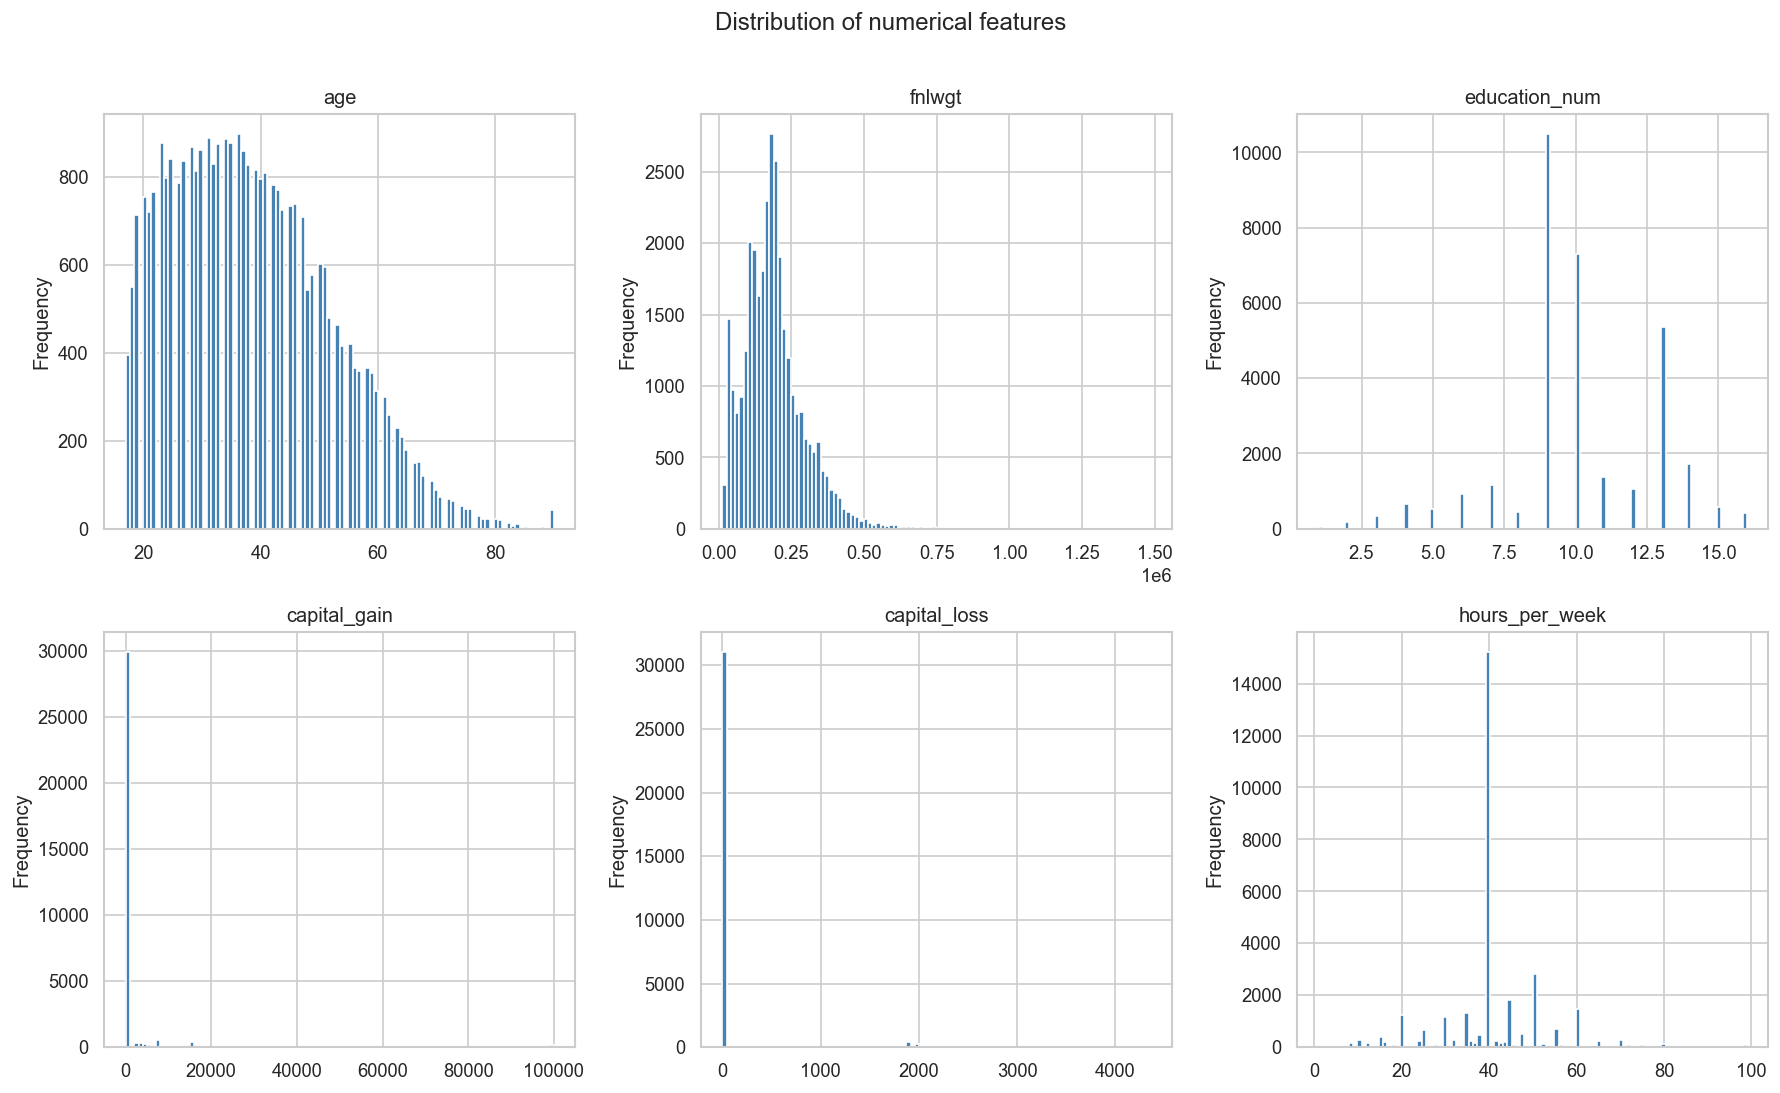

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), NUM_COLS):
    ax.hist(df[col].dropna(), bins=100, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of numerical features", y=1.01)
plt.tight_layout()
plt.show()

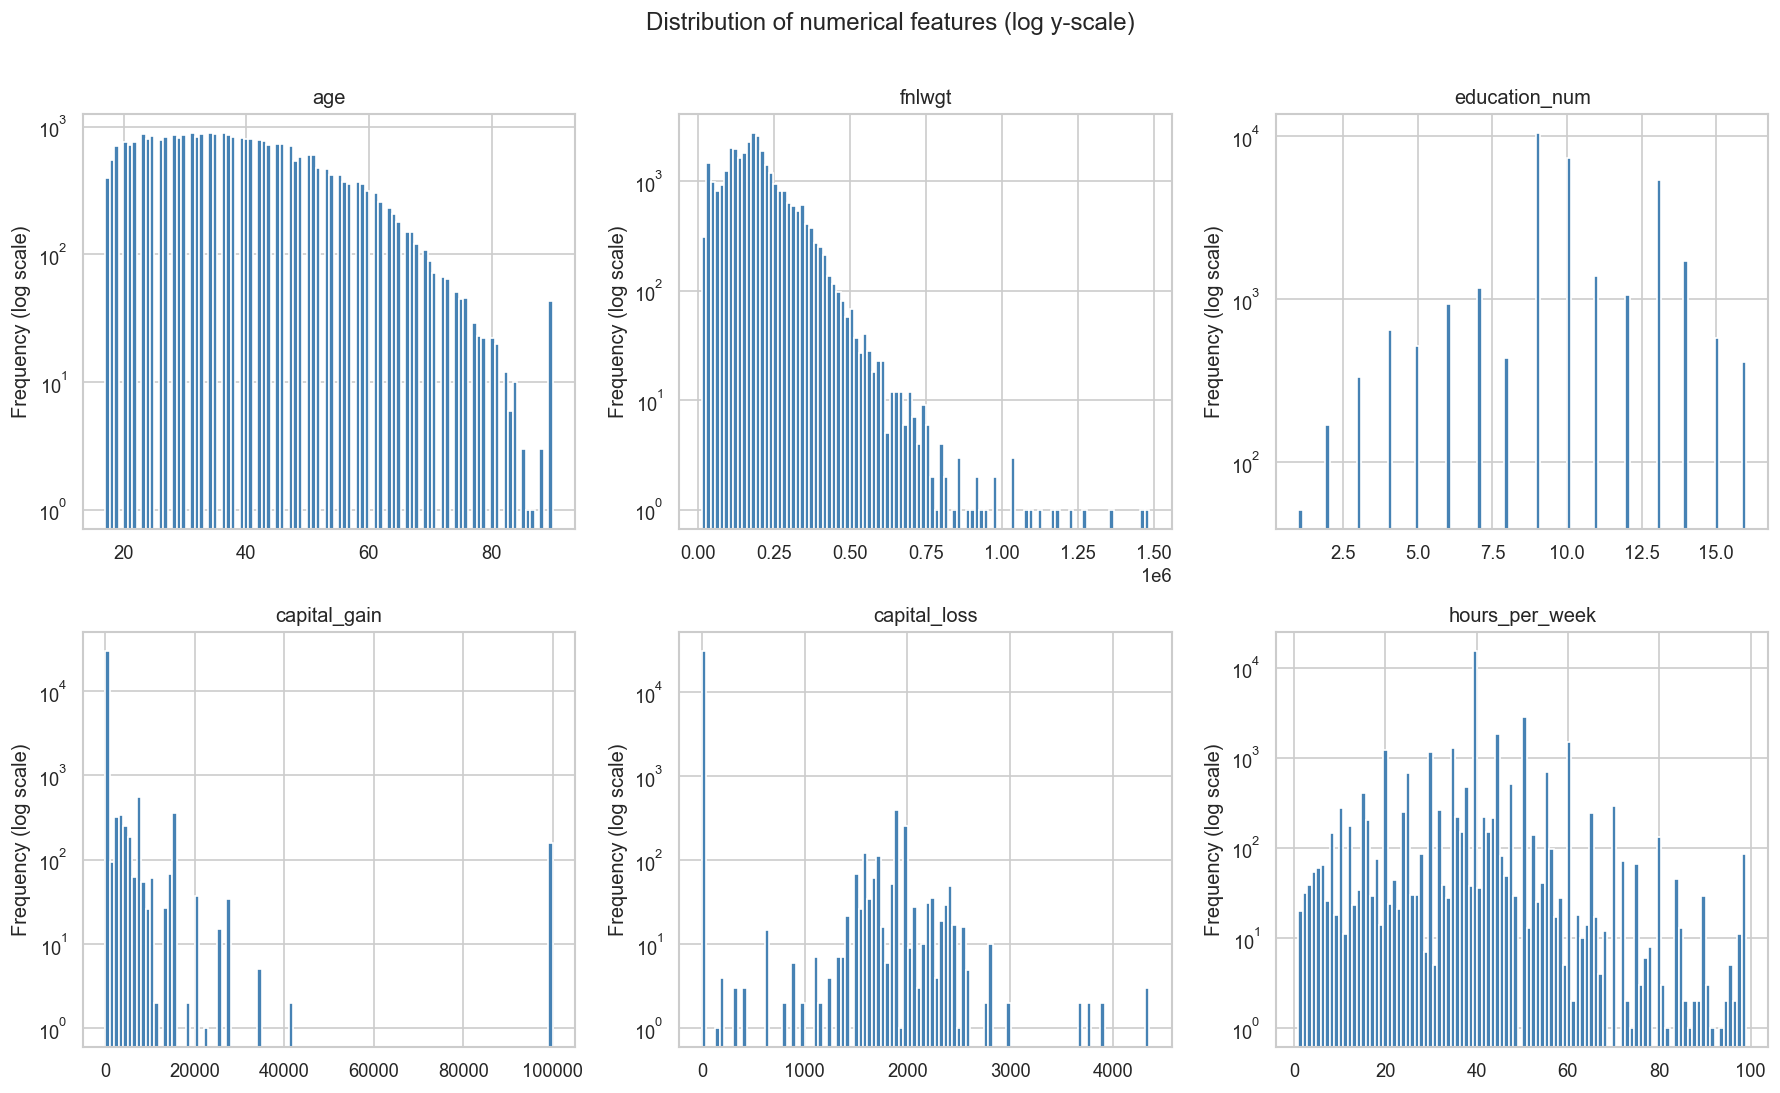

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), NUM_COLS):
    ax.hist(df[col].dropna(), bins=100, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_ylabel("Frequency (log scale)")

plt.suptitle("Distribution of numerical features (log y-scale)", y=1.01)
plt.tight_layout()
plt.show()

The histograms reveal that `capital_gain` has a sharp spike at exactly 99,999. This value stands completely detached from the rest of the distribution. This pattern is characteristic of a censored/missing value. In other words, these are not real observations of exactly $99,999 in capital gains.

The following analysis quantifies this pattern.

### 5.2 Identifying invalid and censored values

In [102]:
# capital_gain: detailed inspection of the upper tail
print("capital_gain: top 15 most frequent values")
print(df["capital_gain"].value_counts().head(15))

n_zero = (df["capital_gain"] == 0).sum()
n_99999 = (df["capital_gain"] == 99999).sum()

print(f"\nZero values: {n_zero} ({n_zero / len(df) * 100:.1f}%)")
print(f"99999: {n_99999} ({n_99999 / len(df) * 100:.1f}%)")

# Distribution of non-zero, and non-99999 values
mask_real = (df["capital_gain"] > 0) & (df["capital_gain"] < 99999)
print(f"\nNon-zero, non-99999 values: {mask_real.sum()}")
print(f"  Min: {df.loc[mask_real, 'capital_gain'].min()}")
print(f"  Max: {df.loc[mask_real, 'capital_gain'].max()}")
print(f"  Median: {df.loc[mask_real, 'capital_gain'].median()}")
print(f"  Mean: {df.loc[mask_real, 'capital_gain'].mean():.0f}")

capital_gain: top 15 most frequent values
capital_gain
0        29849
15024      347
7688       284
7298       246
99999      159
5178        97
3103        97
4386        70
5013        69
8614        55
3325        53
2174        48
10520       43
4064        42
14084       41
Name: count, dtype: int64

Zero values: 29849 (91.7%)
99999: 159 (0.5%)

Non-zero, non-99999 values: 2553
  Min: 114
  Max: 41310
  Median: 6514.0
  Mean: 7516


In [103]:
# capital_loss: detailed inspection
print("capital_loss: top 15 most frequent values")
print(df["capital_loss"].value_counts().head(15))

n_zero_loss = (df["capital_loss"] == 0).sum()
n_total = len(df)

print(f"\nZero values: {n_zero_loss} ({n_zero_loss / n_total * 100:.1f}%)")

# Distribution of non-zero values
mask_real_loss = df["capital_loss"] > 0
n_real_loss = mask_real_loss.sum()
print(f"\nNon-zero values: {n_real_loss} ({n_real_loss / n_total * 100:.1f}%)")
print(f"  Min: {df.loc[mask_real_loss, 'capital_loss'].min()}")
print(f"  Max: {df.loc[mask_real_loss, 'capital_loss'].max()}")
print(f"  Median: {df.loc[mask_real_loss, 'capital_loss'].median()}")
print(f"  Mean: {df.loc[mask_real_loss, 'capital_loss'].mean():.0f}")

capital_loss: top 15 most frequent values
capital_loss
0       31042
1902      202
1977      168
1887      159
1848       51
1485       51
2415       49
1602       47
1740       42
1590       40
1876       39
1672       34
2258       25
1564       25
2001       24
Name: count, dtype: int64

Zero values: 31042 (95.3%)

Non-zero values: 1519 (4.7%)
  Min: 155
  Max: 4356
  Median: 1887.0
  Mean: 1871


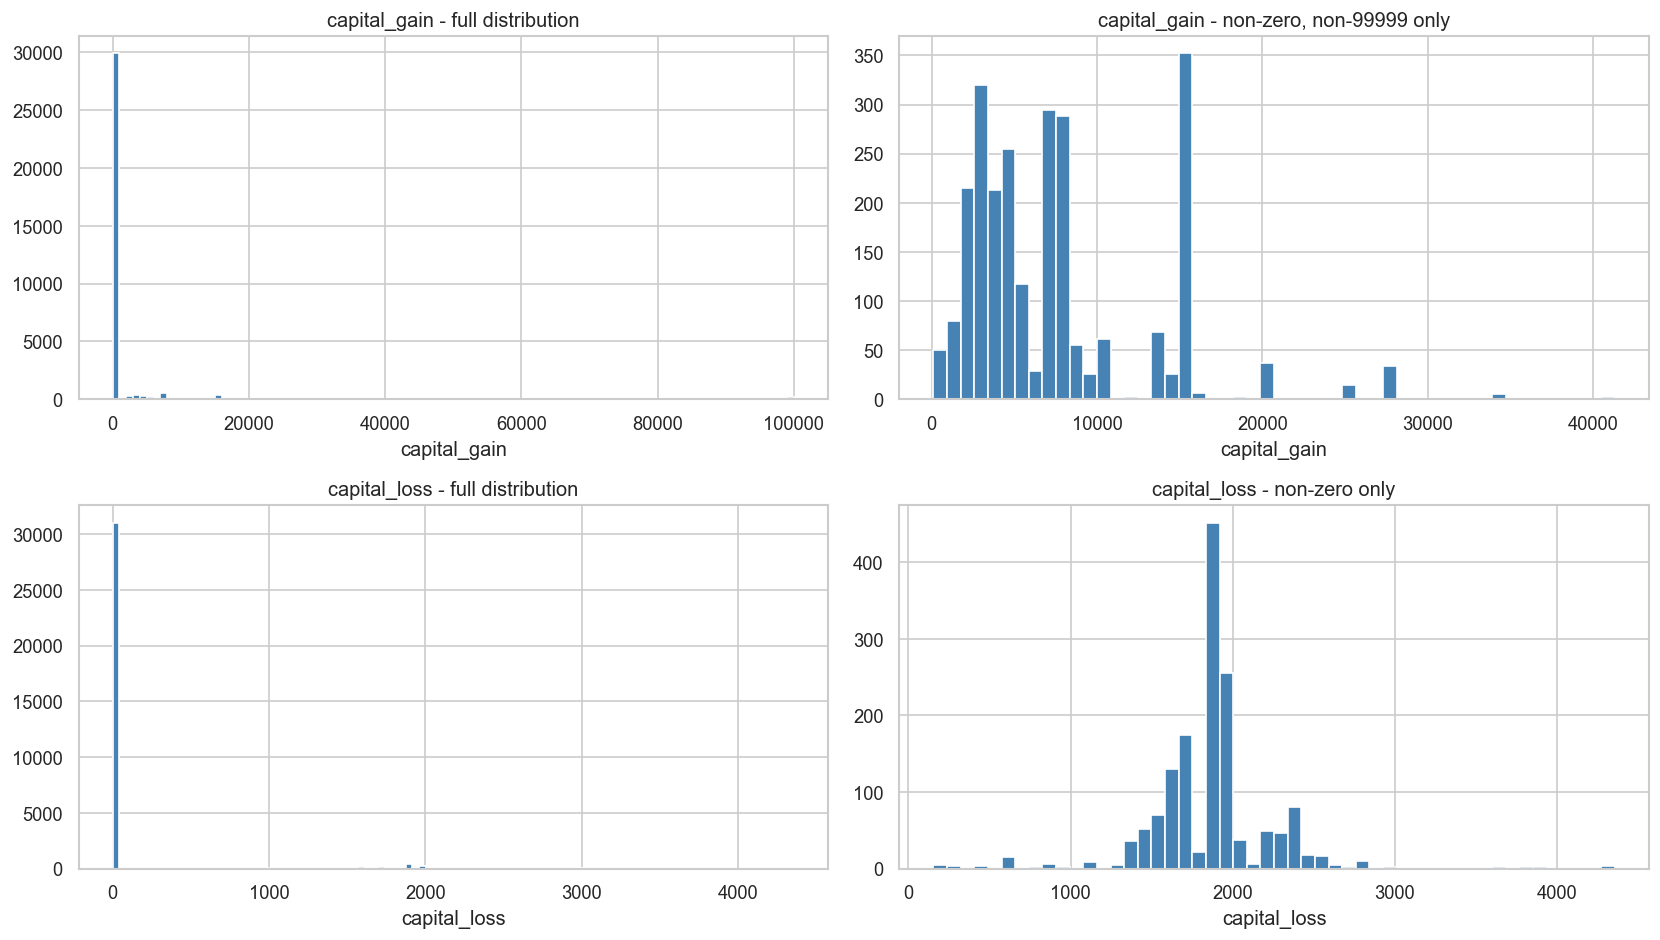

In [104]:
# Visualize capital_gain and capital_loss distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
ax.hist(df["capital_gain"], bins=100, color="steelblue", edgecolor="white")
ax.set_title("capital_gain - full distribution")
ax.set_xlabel("capital_gain")

ax = axes[0, 1]
mask_real_gain = (df["capital_gain"] > 0) & (df["capital_gain"] < 99999)
ax.hist(df.loc[mask_real_gain, "capital_gain"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("capital_gain - non-zero, non-99999 only")
ax.set_xlabel("capital_gain")

ax = axes[1, 0]
ax.hist(df["capital_loss"], bins=100, color="steelblue", edgecolor="white")
ax.set_title("capital_loss - full distribution")
ax.set_xlabel("capital_loss")

ax = axes[1, 1]
ax.hist(df.loc[mask_real_loss, "capital_loss"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("capital_loss - non-zero only")
ax.set_xlabel("capital_loss")

plt.tight_layout()
plt.show()

The value distribution of `capital_gain` confirms the concerns raised in Section 2. Out of 32,561 rows, 29,849 (91.7%) are exactly zero and 159 (0.5%) are exactly 99,999, meaning that only 2,553 observations (7.8%) contain an actual recorded capital gain. Among those real values, the range spans from 114 to 41,310 with a median of 6,514 and a mean of 7,516. The value 99,999 is clearly not a real observation: it is far detached from the next highest genuine value (41,310) and appears as a sharp isolated spike in the distribution. Hence, it should be understood as an invalid entry (i.e. a placeholder for cases where the actual capital gain was not recorded or not reportable). These 159 entries will be replaced with `NaN` in preprocessing and a binary indicator `capital_gain_is_99999` will be created to preserve the information that a value was originally present in that position. Overall, this feature is highly concentrated: over 99% of its values are either zero or invalid, with the informative signal coming from a small minority of observations.

A similar pattern appears in `capital_loss`, although without the invalid-value issue. Out of 32,561 rows, 31,042 (95.3%) are exactly zero, leaving only 1,519 observations (4.7%) with an actual recorded loss. The maximum value is 4,356, which does not show the same detached spike as `capital_gain`. Since the values near the top are part of a continuous distribution rather than an isolated artifact, no entries need to be replaced. Nevertheless, the extreme zero-inflation in both capital columns means that their raw distributions are dominated by a single value, making standard statistical summaries (mean, standard deviation, skewness) largely uninformative.

In [105]:
# Replace invalid capital_gain values with NaN for outlier analysis
df_outlier = df.copy()
df_outlier.loc[df_outlier["capital_gain"] == 99999, "capital_gain"] = np.nan

### 5.3 Outlier detection: IQR method

The **Interquartile Range (IQR)** method is one of the most widely used non-parametric approaches for outlier detection. It defines the interquartile range as the difference between the third quartile (Q3, the 75th percentile) and the first quartile (Q1, the 25th percentile). Two thresholds are established:

- **Mild outliers**: values falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$. These represent unusual but not extreme observations.
- **Severe outliers**: values falling below $Q1 - 3 \times IQR$ or above $Q3 + 3 \times IQR$. These represent highly extreme observations that are far from the bulk of the distribution.

Under a normal distribution, the mild threshold covers approximately 99.3% of the data, while the severe threshold covers approximately 99.98%. The distinction between mild and severe outliers is useful because it allows differentiating between values that are simply uncommon and values that may indicate data errors or fundamentally different populations.

This method makes no assumptions about the underlying distribution, which makes it broadly applicable. However, it has a known limitation with zero-inflated features: when most values are concentrated at a single point (such as zero), both Q1 and Q3 may equal that point, resulting in an IQR of zero. In that case, any value different from the concentration point is flagged as an outlier, which is not meaningful. This situation applies directly to `capital_gain` and `capital_loss` in this dataset.

In [106]:
outlier_info = []
for col in NUM_COLS:
    data = df_outlier[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Mild outlier fences (1.5 * IQR)
    mild_lower = q1 - 1.5 * iqr
    mild_upper = q3 + 1.5 * iqr
    n_mild = ((data < mild_lower) | (data > mild_upper)).sum()

    # Severe outlier fences (3 * IQR)
    severe_lower = q1 - 3 * iqr
    severe_upper = q3 + 3 * iqr
    n_severe = ((data < severe_lower) | (data > severe_upper)).sum()

    outlier_info.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "mild_lower": mild_lower,
        "mild_upper": mild_upper,
        "n_mild": n_mild,
        "pct_mild": round(n_mild / len(data) * 100, 2),
        "severe_lower": severe_lower,
        "severe_upper": severe_upper,
        "n_severe": n_severe,
        "pct_severe": round(n_severe / len(data) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_info).sort_values("pct_mild", ascending=False)
print(outlier_df[[
    "feature", "Q1", "Q3", "IQR",
    "mild_lower", "mild_upper", "n_mild", "pct_mild",
    "severe_lower", "severe_upper", "n_severe", "pct_severe"
]].to_string(index=False))

       feature         Q1         Q3        IQR  mild_lower  mild_upper  n_mild  pct_mild  severe_lower  severe_upper  n_severe  pct_severe
hours_per_week     40.000     45.000      5.000      32.500      52.500    9008    27.660        25.000        60.000      4379      13.450
  capital_gain      0.000      0.000      0.000       0.000       0.000    2553     7.880         0.000         0.000      2553       7.880
  capital_loss      0.000      0.000      0.000       0.000       0.000    1519     4.670         0.000         0.000      1519       4.670
 education_num      9.000     12.000      3.000       4.500      16.500    1198     3.680         0.000        21.000         0       0.000
        fnlwgt 117827.000 237051.000 119224.000  -61009.000  415887.000     992     3.050   -239845.000    594723.000       152       0.470
           age     28.000     48.000     20.000      -2.000      78.000     143     0.440       -32.000       108.000         0       0.000


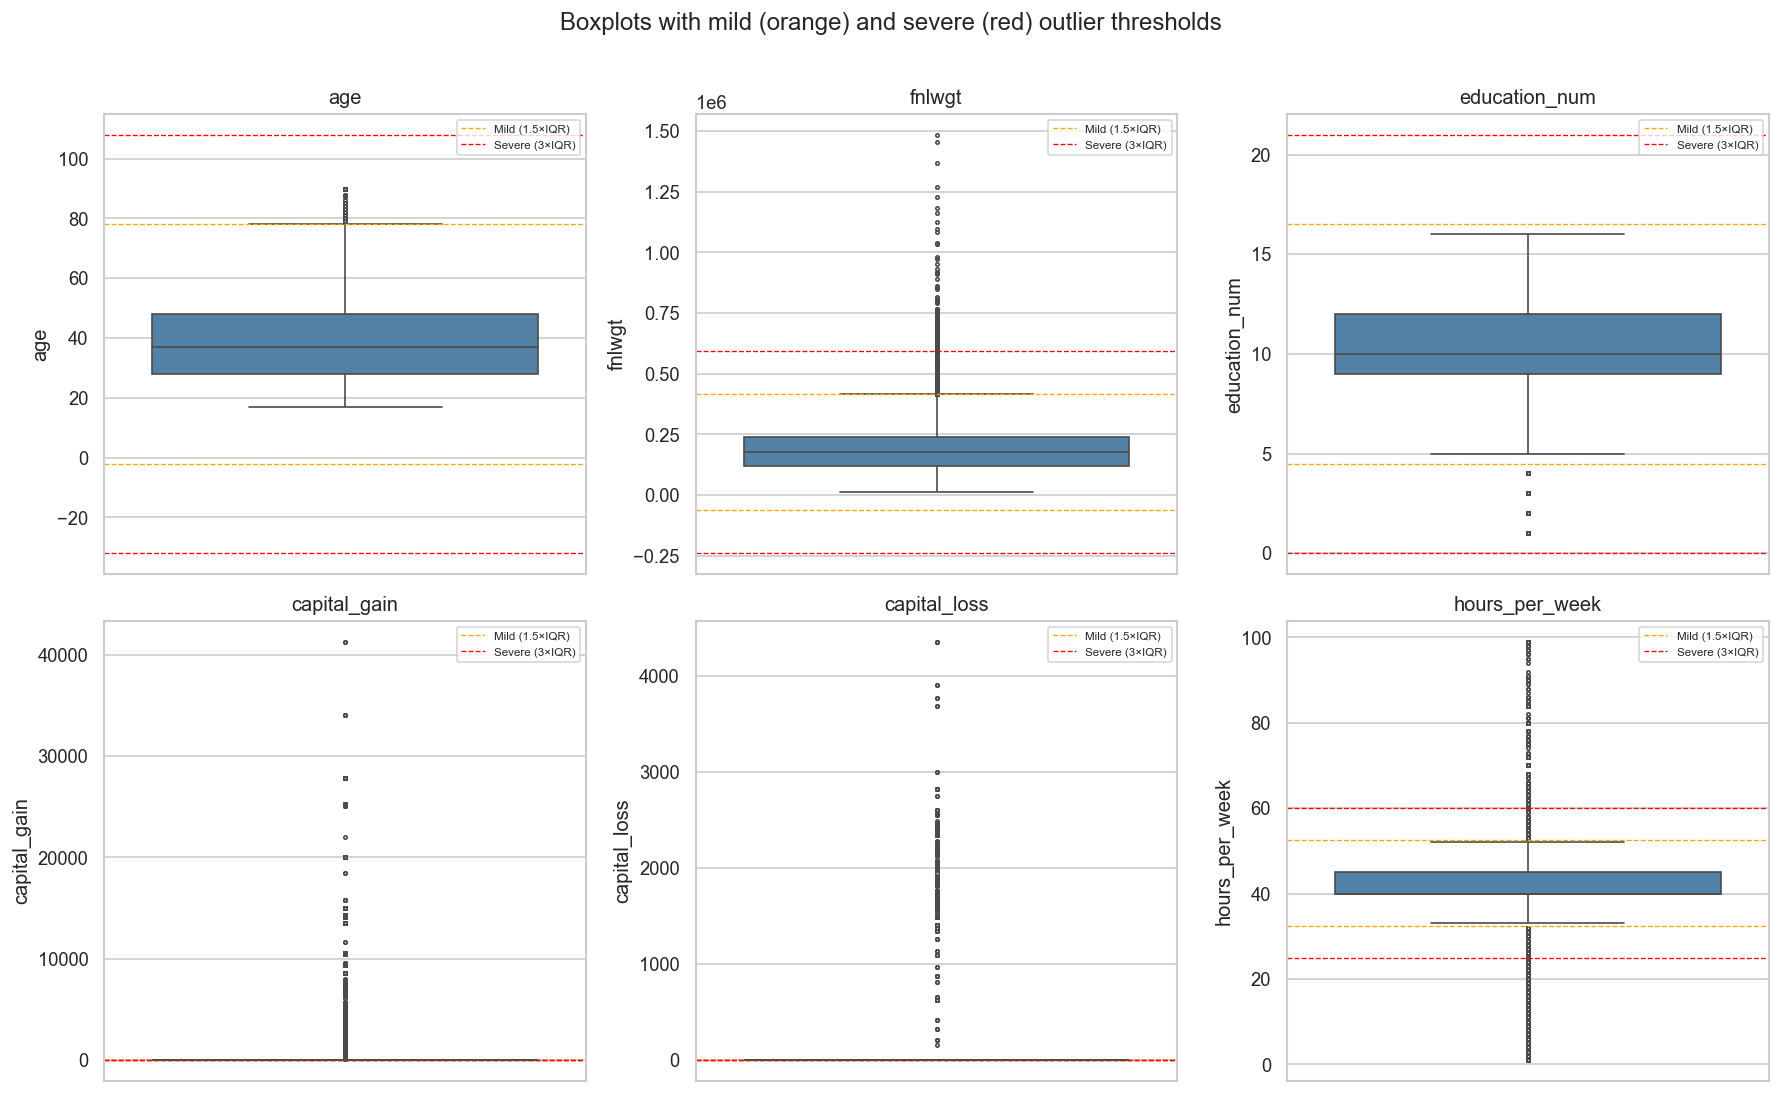

In [107]:
# Boxplots with mild (1.5*IQR) and severe (3*IQR) thresholds marked
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), NUM_COLS):
    data = df_outlier[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    sns.boxplot(data=df_outlier, y=col, ax=ax, color="steelblue", fliersize=2)

    # Mild outlier thresholds (orange dashed lines)
    mild_lower = q1 - 1.5 * iqr
    mild_upper = q3 + 1.5 * iqr
    ax.axhline(mild_lower, color="orange", linestyle="--", linewidth=0.8, label="Mild (1.5×IQR)")
    ax.axhline(mild_upper, color="orange", linestyle="--", linewidth=0.8)

    # Severe outlier thresholds (red dashed lines)
    severe_lower = q1 - 3 * iqr
    severe_upper = q3 + 3 * iqr
    ax.axhline(severe_lower, color="red", linestyle="--", linewidth=0.8, label="Severe (3×IQR)")
    ax.axhline(severe_upper, color="red", linestyle="--", linewidth=0.8)

    ax.set_title(col)
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Boxplots with mild (orange) and severe (red) outlier thresholds", y=1.01)
plt.tight_layout()
plt.show()

The IQR analysis reveals different outlier patterns across features:

- **`hours_per_week`**: this feature has the highest percentage of mild outliers (27.66%, 9,008 rows), with 4,379 severe outliers (13.45%). The mild fences are 32.5 and 52.5 hours, meaning that anyone working part-time or more than a standard overtime schedule is flagged. The severe threshold at 60 hours still captures a substantial number of observations.
- **`capital_gain`** and **`capital_loss`**: both have an IQR of zero because Q1, Q3, and the median are all zero due to extreme zero-inflation. As a consequence, every non-zero value is flagged as both a mild and severe outlier (2,553 for `capital_gain`, 1,519 for `capital_loss`).
- **`education_num`**: 1,198 mild outliers (3.68%) fall below the lower fence of 4.5, corresponding to individuals with very low education levels (Preschool through 4th grade). No severe outliers exist.
- **`fnlwgt`**: 992 mild outliers (3.05%) and 152 severe outliers (0.47%) are detected in the upper tail. Since this feature is a census sampling weight and not a characteristic of the individual, the outliers reflect the survey design rather than unusual persons.
- **`age`**: only 143 mild outliers (0.44%) are detected above the upper fence of 78 years, and no severe outliers exist. These represent elderly individuals who are genuine members of the population.

Overall, the IQR method is not applicable to `capital_gain` and `capital_loss` due to their zero-inflated distributions, which produce an IQR of zero and flag every non-zero value as an outlier. For the remaining features where the method produces meaningful results (`age`, `fnlwgt`, `education_num`, `hours_per_week`), the flagged values correspond to plausible real-world observations (elderly individuals, part-time or overworked employees, people with minimal education) rather than data errors or anomalies. Therefore, no rows will be removed based on this analysis.

### 5.4 Outlier detection: Isolation Forest

**Isolation Forest** is a tree-based unsupervised method specifically designed for outlier detection. Unlike statistical methods like IQR that evaluate each feature independently, Isolation Forest operates in the multivariate space, meaning it can detect observations that are not outliers in any single feature but become anomalous when considering multiple features simultaneously.

The algorithm works by building an ensemble of random decision trees (called isolation trees), where each tree recursively partitions the data by selecting a random feature and a random split point within that feature's range. The key principle is that **outliers are easier to isolate**: since they lie in sparse regions of the feature space, fewer random splits are needed to separate them from the rest of the data. Normal observations, being surrounded by many similar points, require more splits to be isolated.

Each observation receives an anomaly score based on the average path length (number of splits) needed to isolate it across all trees in the ensemble. Shorter average paths correspond to more anomalous points.

Note that `fnlwgt` is excluded since it is a census sampling weight and not a characteristic of the individual.

In [108]:
from sklearn.ensemble import IsolationForest

# Prepare data: use numerical features excluding fnlwgt, drop NaN rows
iso_features = [c for c in NUM_COLS if c != "fnlwgt"]
num_data = df_outlier[iso_features].dropna()

# Fit Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    random_state=SEED
)
iso_labels = iso_forest.fit_predict(num_data)  # -1 = outlier, 1 = inlier
iso_scores = iso_forest.decision_function(num_data)  # lower = more anomalous

n_iso_outliers = (iso_labels == -1).sum()
print(f"Isolation Forest outliers: {n_iso_outliers} ({n_iso_outliers / len(num_data) * 100:.2f}%)")

Isolation Forest outliers: 4729 (14.59%)


In [109]:
# Profile of outliers vs inliers
num_data_labelled = num_data.copy()
num_data_labelled["is_outlier"] = (iso_labels == -1).astype(int)

print("Mean values: outliers vs inliers")
print(num_data_labelled.groupby("is_outlier")[iso_features].mean().round(1).T)

print("\nMedian values: outliers vs inliers")
print(num_data_labelled.groupby("is_outlier")[iso_features].median().round(1).T)

print("\nStd values: outliers vs inliers")
print(num_data_labelled.groupby("is_outlier")[iso_features].std().round(1).T)

print(f"\nOutlier counts")
print(f"Inliers: {(iso_labels == 1).sum()}")
print(f"Outliers: {(iso_labels == -1).sum()}")

# Non-zero rates for capital columns
print("\nNon-zero rates: outliers vs inliers")
for col in ["capital_gain", "capital_loss"]:
    outlier_nonzero = (num_data.loc[iso_labels == -1, col] > 0).mean()
    inlier_nonzero = (num_data.loc[iso_labels == 1, col] > 0).mean()
    print(f"{col}:")
    print(f"  Outlier non-zero rate: {outlier_nonzero:.3f}")
    print(f"  Inlier non-zero rate:  {inlier_nonzero:.3f}")

# Income distribution of outliers vs inliers
print("\nIncome distribution: outliers vs inliers")
target_aligned = df_outlier.loc[num_data.index, TARGET]
print("Outliers:")
print(target_aligned[iso_labels == -1].value_counts(normalize=True).round(3).to_string())
print("\nInliers:")
print(target_aligned[iso_labels == 1].value_counts(normalize=True).round(3).to_string())

Mean values: outliers vs inliers
is_outlier           0        1
age             37.300   45.900
education_num   10.100   10.000
capital_gain   135.700 3263.500
capital_loss     1.000  595.600
hours_per_week  40.300   40.800

Median values: outliers vs inliers
is_outlier          0      1
age            36.000 45.000
education_num  10.000 10.000
capital_gain    0.000  0.000
capital_loss    0.000  0.000
hours_per_week 40.000 40.000

Std values: outliers vs inliers
is_outlier           0        1
age             12.400   17.500
education_num    2.300    3.800
capital_gain   784.600 5741.200
capital_loss    28.100  900.700
hours_per_week  10.200   20.800

Outlier counts
Inliers: 27673
Outliers: 4729

Non-zero rates: outliers vs inliers
capital_gain:
  Outlier non-zero rate: 0.333
  Inlier non-zero rate:  0.035
capital_loss:
  Outlier non-zero rate: 0.313
  Inlier non-zero rate:  0.001

Income distribution: outliers vs inliers
Outliers:
income
<=50K   0.539
>50K    0.461

Inliers:
income
<

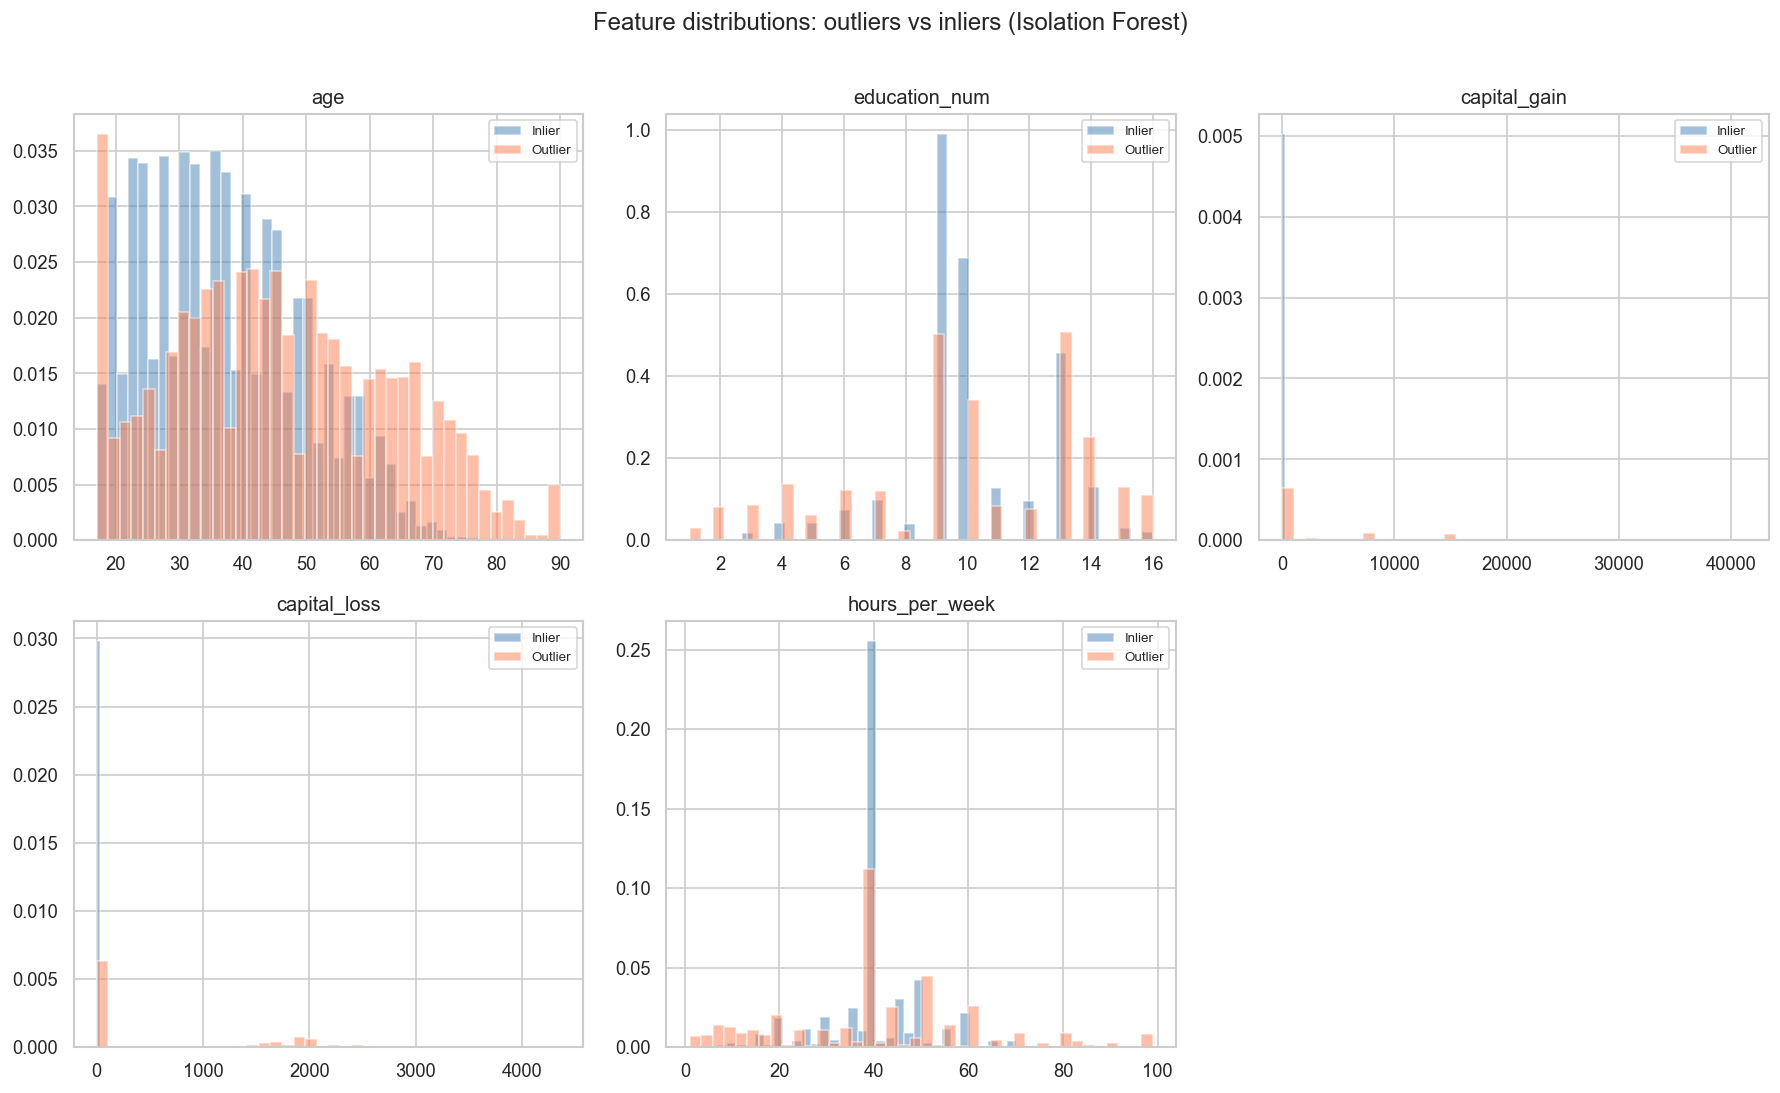

In [110]:
# Feature distributions: outliers vs inliers
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()
for i, col in enumerate(iso_features):
    ax = axes_flat[i]
    for label, color, name in [(1, "steelblue", "Inlier"), (-1, "coral", "Outlier")]:
        subset = num_data.loc[iso_labels == label, col]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(len(iso_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Feature distributions: outliers vs inliers (Isolation Forest)", y=1.01)
plt.tight_layout()
plt.show()

The Isolation Forest identifies a group of observations that differ from the main population primarily through the capital columns and age. The outlier group has substantially higher mean values for both `capital_gain` and `capital_loss`, and a much larger proportion of non-zero entries in both columns compared to the inlier group. They also tend to be older and show higher variability across all features, particularly in `hours_per_week` and `education_num`. Interestingly, `education_num` and `hours_per_week` medians are virtually identical between both groups, meaning the separation is driven by the capital columns and age rather than by working patterns or education level.

A particularly revealing finding is the income distribution: the outlier group is almost evenly split between `<=50K` and `>50K`, while the inlier group follows the overall dataset imbalance heavily favoring `<=50K`. This suggests that the Isolation Forest is capturing a subset of the population with higher financial activity, specifically individuals with capital gains or losses who tend to be older and wealthier. These are not data errors or anomalies in the traditional sense but rather a distinct socioeconomic segment of the population.

This reinforces the conclusion from the IQR analysis. No rows should be removed based on outlier detection, as the extreme values in this dataset reflect real variation in the population rather than data quality problems.

## 6. Target variable and bivariate analysis

This section examines the target variable distribution and then measures how strongly each feature in the dataset associates with income. It combines the target overview, bivariate correlations, and class-conditional interaction effects into a single analysis.

### 6.1 Target distribution

In [111]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": target_counts, "percentatge": target_pct.round(1)})
print(summary)

ratio = target_counts["<=50K"] / target_counts[">50K"]
print(f"\nImbalance ratio (<=50K : >50K): {ratio:.2f} : 1")

        count  percentatge
income                    
<=50K   24720       75.900
>50K     7841       24.100

Imbalance ratio (<=50K : >50K): 3.15 : 1


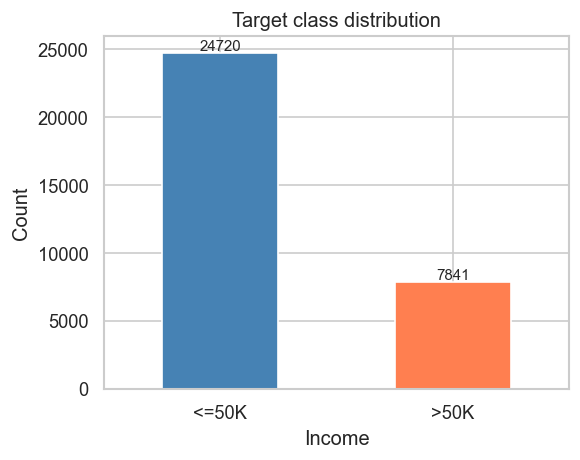

In [112]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["steelblue", "coral"]
target_counts.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Target class distribution")
ax.set_xlabel("Income")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
annotate_bars(ax)
plt.tight_layout()
plt.show()

The target variable is clearly imbalanced, with roughly 76% of the samples belonging to the `<=50K` class and 24% to the `>50K` class, representing a 3.15 to 1 ratio. While this distribution is not extreme enough to require aggressive resampling techniques, it is significant enough that standard performance metrics could be highly misleading.

This fact will clearly have to be taken into account when modeling, since evaluation metrics that are sensitive to class imbalance, such as F1-score or precision-recall curves, will need to be prioritized over standard accuracy to ensure the model effectively learns to identify both income groups and does not always predict the dominant class.

### 6.2 Numerical features vs income class

To analyze the behavior of the continuous variables relative to the target income class, both the central tendencies and the overall distributions are examined. The boxplots illustrate the variations in medians, quartiles, and outliers between the groups, while the overlapping histograms reveal the shape and density shifts of each feature across the `<=50K` and `>50K` classes.

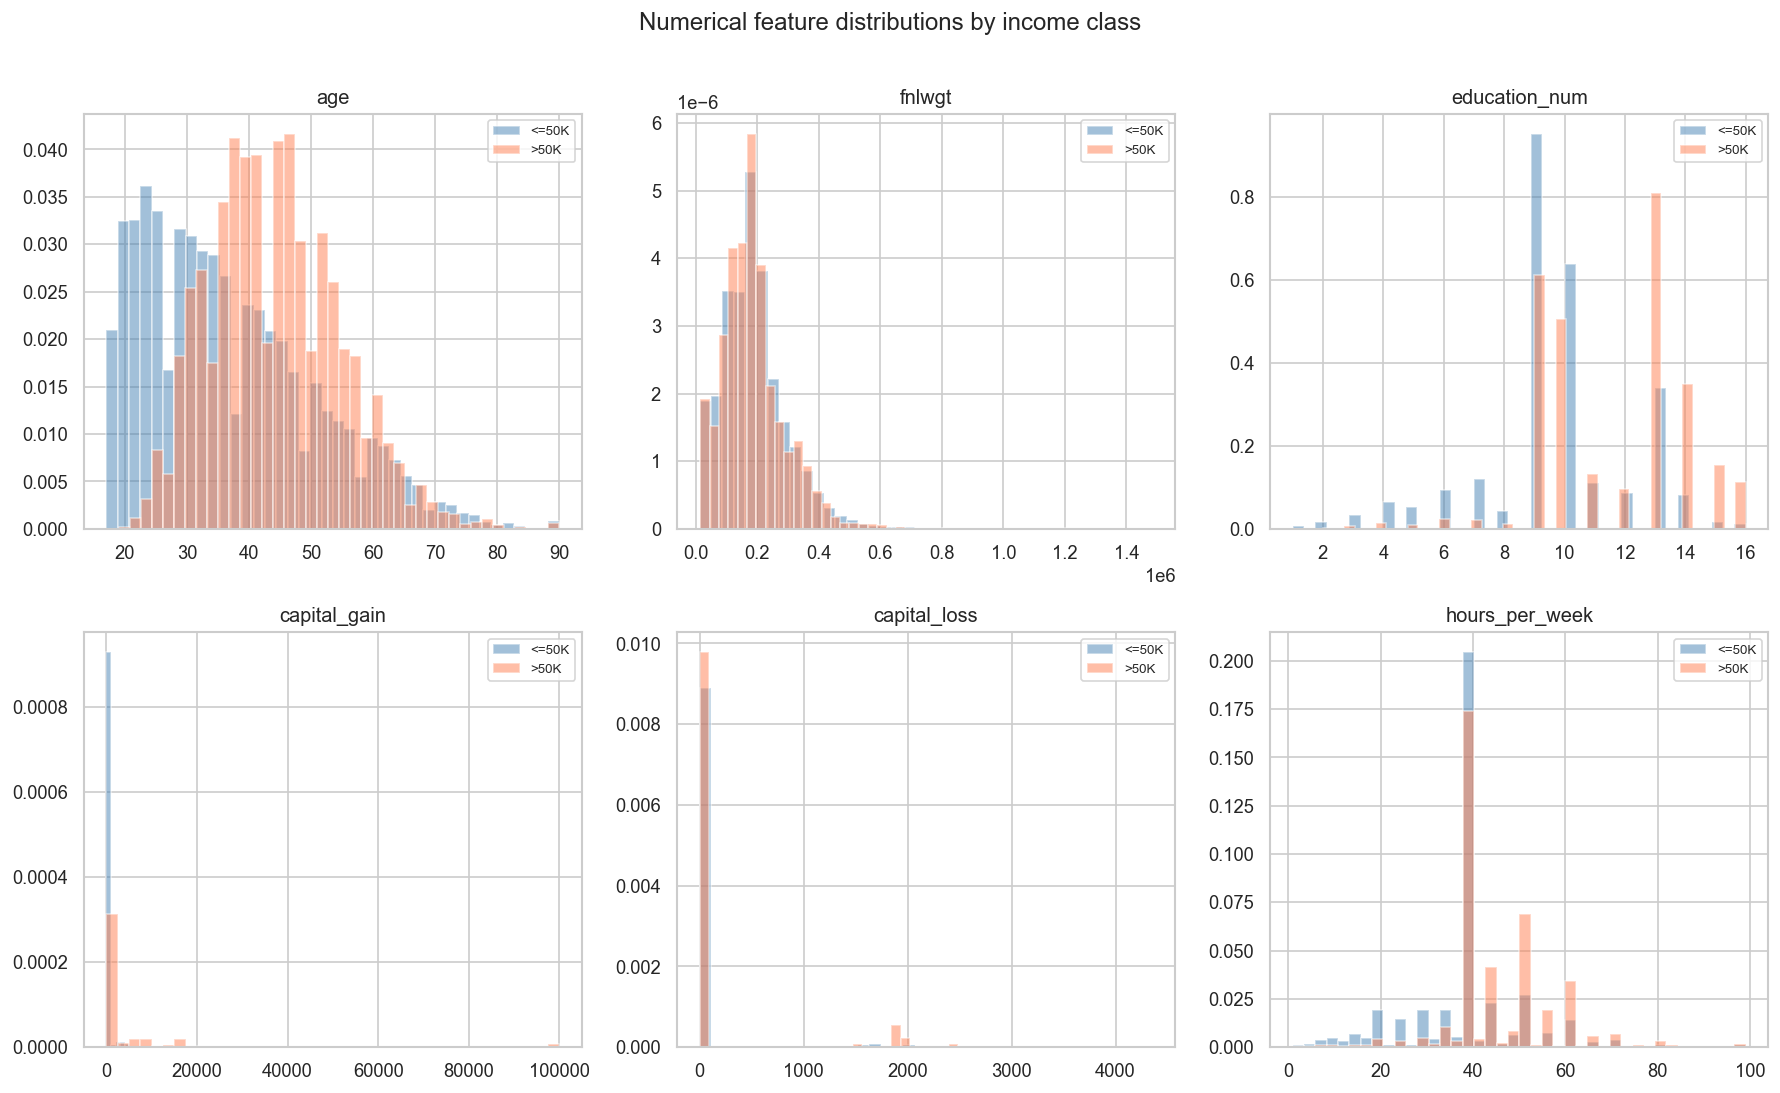

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), NUM_COLS):
    for label, color in [("<=50K", "steelblue"), (">50K", "coral")]:
        subset = df.loc[df[TARGET] == label, col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Numerical feature distributions by income class", y=1.01)
plt.tight_layout()
plt.show()

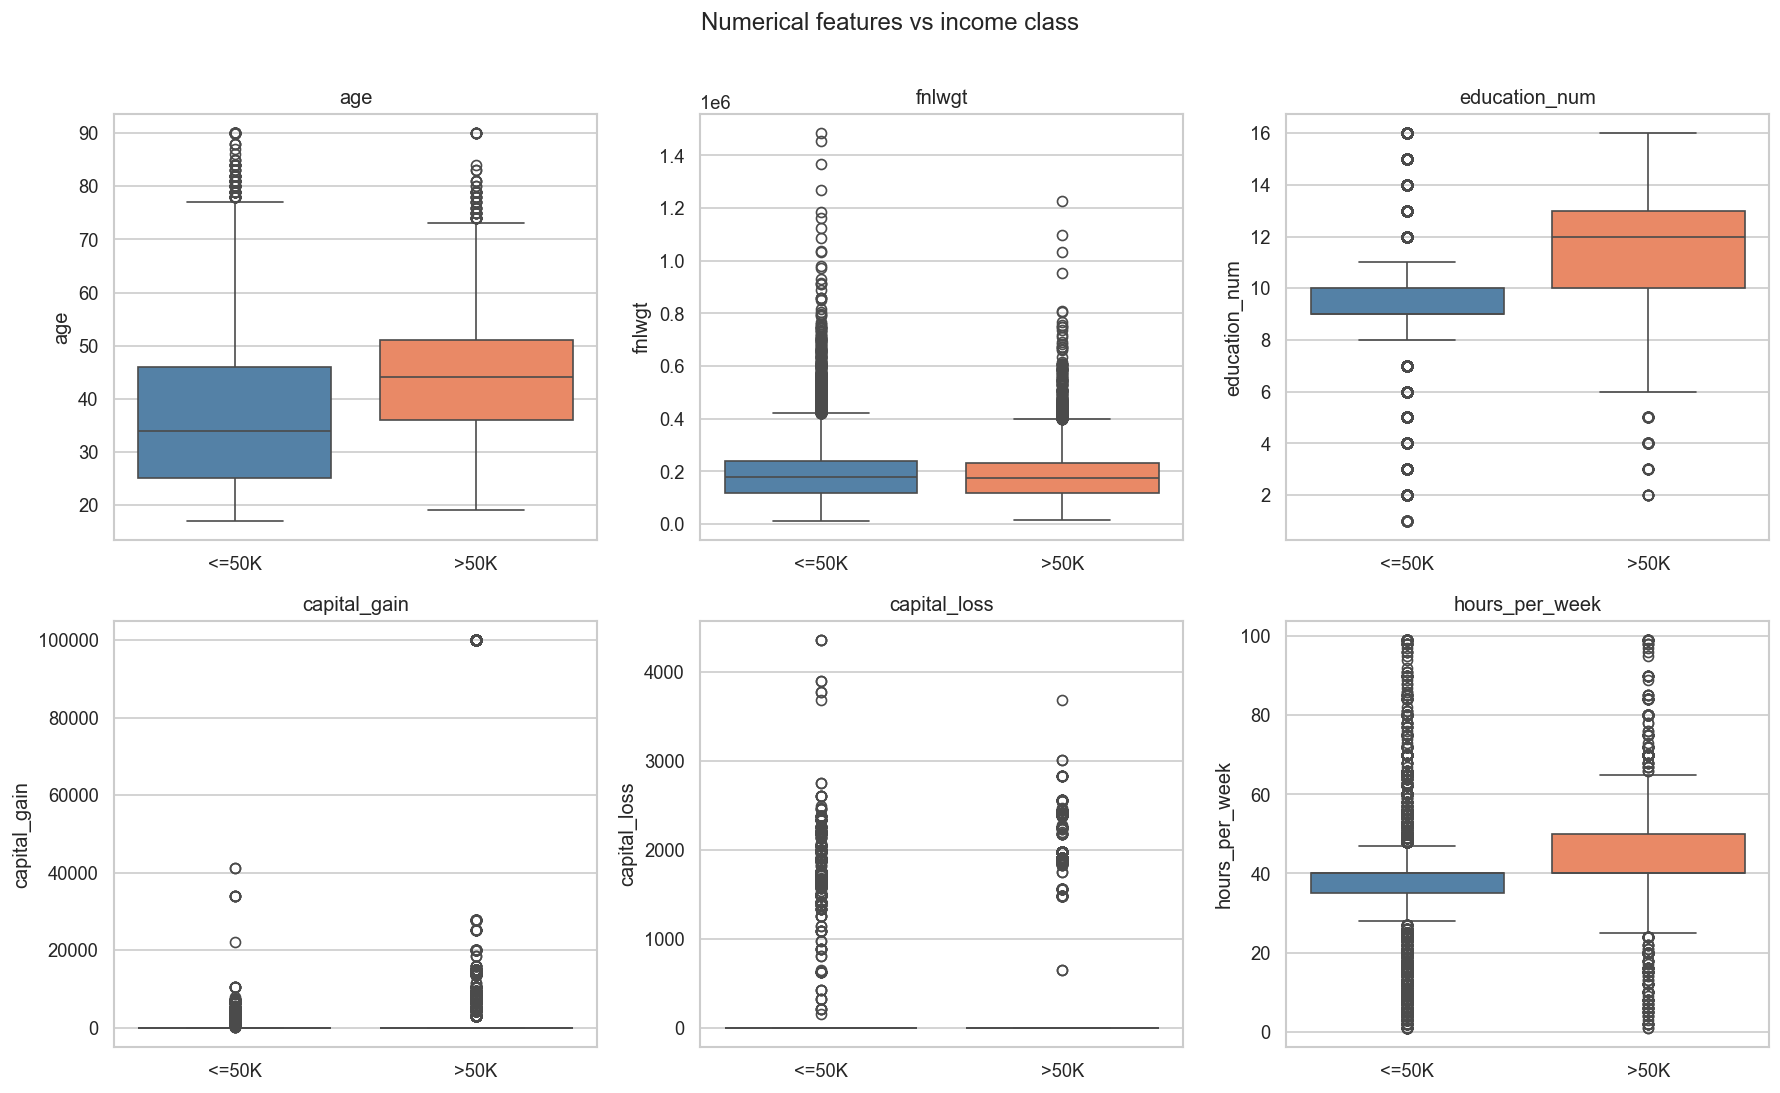

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, ax=ax, palette=colors, legend=False)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Numerical features vs income class", y=1.01)
plt.tight_layout()
plt.show()

The boxplots and distribution histograms provide key insights into how the numerical features relate to the target income class:

* **`age`**: There is a clear distributional shift showing that older individuals tend to have higher incomes. The majority of individuals earning `>50K` are concentrated between their mid-30s and early 50s, whereas the `<=50K` class is heavily skewed toward younger individuals in their 20s and early 30s.

* **`education_num`**: Higher levels of education strongly correlate with higher income. The median education level for the `>50K` group is notably higher compared to the `<=50K` group, which peaks sharply around high school graduation or some college experience.

* **`hours_per_week`**: Individuals earning `>50K` generally work more hours, with a median centered firmly at 40 hours per week and a significant portion extending into the 45–50 hour range. While 40 hours is the dominant baseline for both groups, the `<=50K` group shows a much wider spread below 40 hours, highlighting part-time workers.

* **`capital_gain` and `capital_loss`**: Both features are highly sparse and heavily skewed toward zero for the vast majority of the population. However, extreme outliers, particularly those with exceptionally high capital gains, belong almost exclusively to the `>50K` income bracket, suggesting these features will serve as strong, one-sided predictors.

* **`fnlwgt`**: The distributions of the population weights are virtually identical and perfectly overlapping for both income classes. This indicates that `fnlwgt` holds little to no predictive power for distinguishing between income levels.

### 6.3 Categorical features vs income class

To evaluate the relationship between the categorical variables and the target income class, the distribution and success rate of the categories are analyzed. The following sections detail the breakdown of income levels across different subcategories, highlighting which groups show a higher propensity for earning above 50K.

* **`workclass`**: The vast majority of the sample belongs to the `Private` sector, which exhibits a baseline success rate of approximately 21.9%. The highest concentration of high earners is found within the `Self-emp-inc` (Self-employed incorporated) category, where over 55.7% earn above 50K, followed by `Federal-gov` employees at 38.6%. Conversely, individuals who have `Never-worked` or are `Without-pay` show a zero percent rate of high income, while unclassified records (`NaN`) display a low rate of 10.4%.
* **`education`**: A strong positive correlation is observed between formal education levels and income status. Advanced degrees show the highest proportions of high earners, led by `Doctorate` (74.1%) and `Prof-school` (73.4%), followed closely by `Masters` graduates at 55.7%. In contrast, individuals with high school education or less drop significantly in high-income representation, with `HS-grad` at 16.0% and several primary or early secondary education cohorts falling below 8%.

In [115]:
def cat_income_summary(col, top_n=20):
    """Count and >50K rate for each category value."""
    counts = df[col].value_counts(dropna=False).head(top_n)
    rate = (
        df.groupby(col, dropna=False)[TARGET]
        .apply(lambda s: (s == ">50K").mean())
        .reindex(counts.index)
    )
    return pd.DataFrame({"count": counts, ">50K_rate": rate.round(3)})

for col in CAT_COLS:
    print(f"  {col}")
    print(cat_income_summary(col))
    print()

  workclass
                  count  >50K_rate
workclass                         
Private           22696      0.219
Self-emp-not-inc   2541      0.285
Local-gov          2093      0.295
NaN                1836      0.104
State-gov          1298      0.272
Self-emp-inc       1116      0.557
Federal-gov         960      0.386
Without-pay          14      0.000
Never-worked          7      0.000

  education
              count  >50K_rate
education                     
HS-grad       10501      0.160
Some-college   7291      0.190
Bachelors      5355      0.415
Masters        1723      0.557
Assoc-voc      1382      0.261
11th           1175      0.051
Assoc-acdm     1067      0.248
10th            933      0.066
7th-8th         646      0.062
Prof-school     576      0.734
9th             514      0.053
12th            433      0.076
Doctorate       413      0.741
5th-6th         333      0.048
1st-4th         168      0.036
Preschool        51      0.000

  marital_status
              

C:\Users\berta\AppData\Local\Temp\ipykernel_19732\614578321.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
C:\Users\berta\AppData\Local\Temp\ipykernel_19732\614578321.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
C:\Users\berta\AppData\Local\Temp\ipykernel_19732\614578321.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
C:\Users\berta\AppData\Local\Temp\ipykernel_19732\614578321.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

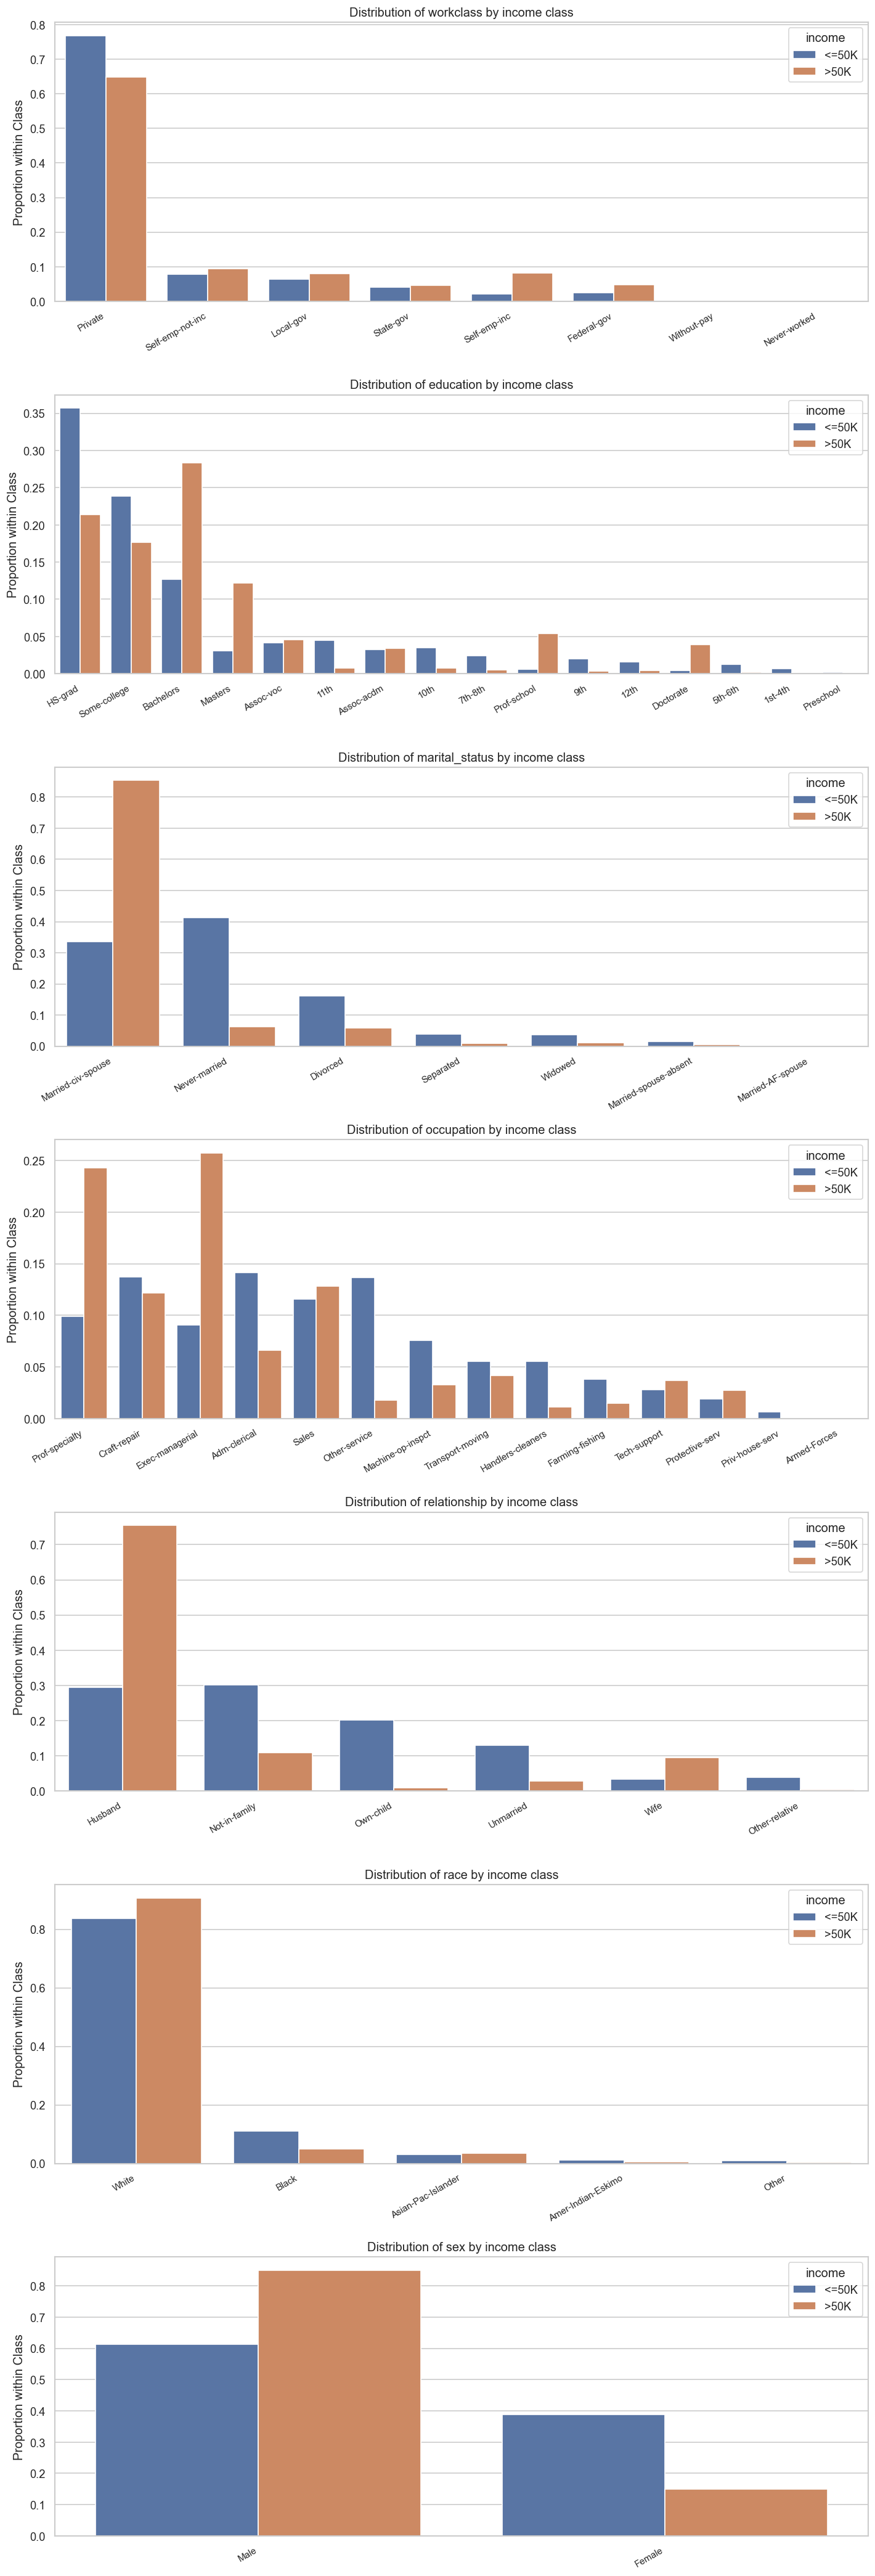

In [116]:
# Define categorical features and target
plot_cats = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex"]
TARGET = "income"  # Adjusted to match typical dataset naming; change to your TARGET variable if different

# Set up the subplotsgrid
fig, axes = plt.subplots(len(plot_cats), 1, figsize=(12, 5 * len(plot_cats)))
sns.set_style("whitegrid")

for ax, col in zip(axes, plot_cats):
    # Calculate the percentage within each income class to normalize the imbalanced target
    df_pct = (
        df.groupby(TARGET)[col]
        .value_counts(normalize=True)
        .rename("percentage")
        .reset_index()
    )
    
    # Determine order based on the global frequency of the category to keep it clean
    category_order = df[col].value_counts().index
    
    # Draw a grouped bar plot comparing the distributions side by side
    sns.barplot(
        data=df_pct,
        x=col,
        y="percentage",
        hue=TARGET,
        order=category_order,
        ax=ax,
        palette=["#4c72b0", "#dd8452"]  # Muted blue and orange matching the numerical plots
    )
    
    # Formatting to match the styling of the numerical plots section
    ax.set_title(f"Distribution of {col} by income class", fontsize=12)
    ax.set_ylabel("Proportion within Class")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.legend(title=TARGET)

plt.tight_layout()
plt.show()

The categorical variables reveal distinct variations in high-income distribution across different demographic and employment classifications:

* **`workclass`**: The vast majority of the sample belongs to the `Private` sector, which exhibits a baseline high-income rate of approximately 21.9%. The highest concentration of high earners is found within the `Self-emp-inc` category, where 55.7% earn above 50K, followed by `Federal-gov` employees at 38.6%. Conversely, individuals who have `Never-worked` or are `Without-pay` show a zero percent rate of high income, while unclassified records (`NaN`) display a low rate of 10.4%.

* **`education`**: A strong positive correlation is observed between formal education levels and income status. Advanced degrees show the highest proportions of high earners, led by `Doctorate` (74.1%) and `Prof-school` (73.4%), followed closely by `Masters` graduates at 55.7%. In contrast, individuals with high school education or less drop significantly in high-income representation, with `HS-grad` at 16.0% and several primary or early secondary education cohorts falling below 8%.

* **`occupation`**: `Exec-managerial` and `Prof-specialty` show the highest likelihood of high income, with rates of 48.4% and 44.9% respectively. In contrast, positions such as `Other-service` (4.2%) and `Priv-house-serv` (0.7%) exhibit exceptionally low rates of earning above 50K.

* **`marital_status`**: Married individuals (`Married-civ-spouse` and `Married-AF-spouse`) are significantly more likely to earn above 50K compared to those who are single, divorced, or separated, indicating that marital status is a strong indicator of income class.

* **`relationship`**: The categories of `Husband` (44.9%) and `Wife` (47.5%) display the highest proportions of high earners. Conversely, categories indicating dependency or non-familial status, such as `Own-child` (1.3%) and `Unmarried` (6.3%), show very low rates of high-income representation.

* **`race`**: Group-level variances are visible, with `Asian-Pac-Islander` (26.6%) and `White` (25.6%) populations showing higher rates of earning above 50K compared to `Black` (12.4%), `Amer-Indian-Eskimo` (11.6%), and `Other` (9.2%) categories.

* **`sex`**: A noticeable disparity exists between genders; males exhibit a high-income rate of 30.6%, whereas females show a rate of 10.9%.

* **`native_country`**: The feature is heavily dominated by the United States, which exhibits a baseline high-income rate of 24.6%. While certain small-sample countries like India (40.0%), Japan (38.7%), and Germany (32.1%) show higher proportions of high earners, others like Mexico (5.1%) and the Dominican Republic (2.9%) fall well below the average.

### 6.4 Zero-inflation in capital columns and predictive signal

As established in Section 5, both capital columns are extremely zero-inflated. The following analysis checks whether the distinction between zero and non-zero values carries predictive signal for income.

In [117]:
for col in ["capital_gain", "capital_loss"]:
    n_zero = (df[col] == 0).sum()
    n_nonzero = (df[col] > 0).sum()
    print(f"{col}:")
    print(f"  Zero: {n_zero} ({n_zero / len(df) * 100:.1f}%)")
    print(f"  Non-zero: {n_nonzero} ({n_nonzero / len(df) * 100:.1f}%)")
    
    # Among non-zero values, is there class separation?
    nonzero_mask = df[col] > 0
    rate_high = (df.loc[nonzero_mask, TARGET] == ">50K").mean()
    rate_zero = (df.loc[~nonzero_mask, TARGET] == ">50K").mean()
    print(f"  >50K rate when non-zero: {rate_high:.3f}")
    print(f"  >50K rate when zero:     {rate_zero:.3f}")
    print()

capital_gain:
  Zero: 29849 (91.7%)
  Non-zero: 2712 (8.3%)
  >50K rate when non-zero: 0.618
  >50K rate when zero:     0.207

capital_loss:
  Zero: 31042 (95.3%)
  Non-zero: 1519 (4.7%)
  >50K rate when non-zero: 0.509
  >50K rate when zero:     0.228



An evaluation of the data confirms that a strong predictive signal exists when distinguishing between zero and non-zero values for both capital metrics:

* **`capital_gain`**: The vast majority of people (91.7%) have zero investment gains, and only about 20.7% of them earn above 50K. However, for the small group of people who do report capital gains, the chance of earning above 50K increases significantly to 61.8%, demonstrating that the presence of capital gains serves as a highly accurate positive indicator for high-income status.

* **`capital_loss`**: Similarly, 95.3% of the dataset shows zero investment losses. However, for the remaining 4.7% who do report a loss, the rate of high earners climbs to 50.9%, compared to just 22.8% for the group with zero losses, meaning that even having investments to lose in the first place shows that a person is much more likely to be in the higher income group.

This is consistent with the fact that both variables are heavily grouped at zero, making the mere presence of any investment activity a strong hint about a person's financial situation. Hence, in preprocessing, it might be a good idea to define a binary variable for each column, such as `has_capital_gain` and `has_capital_loss`, that might allow the model to easily classify if the person is in the higher income group based on whether they have investment activity at all.

### 6.5 Unified feature association ranking

Two measures are used to rank feature associations with income. **Point-biserial correlation** (equivalent to Pearson correlation when one variable is binary) is used for numerical features against the binarized target. **Cramér's V** is used for categorical features against the target. These two measures are not directly comparable in scale, but they allow ranking features within each type.

In [118]:
income_bin = (df[TARGET] == ">50K").astype(int)

pb_corr = {}
for col in NUM_COLS:
    valid = df[col].dropna()
    valid_target = income_bin.loc[valid.index]
    r, p = stats.pointbiserialr(valid_target, valid)
    pb_corr[col] = {"r": round(r, 3), "p": round(p, 6)}

pb_df = pd.DataFrame(pb_corr).T.sort_values("r", key=abs, ascending=False)
print("Point-biserial correlation with income sorted by |r|.")
print(pb_df)

Point-biserial correlation with income sorted by |r|.
                    r     p
education_num   0.335 0.000
age             0.234 0.000
hours_per_week  0.230 0.000
capital_gain    0.223 0.000
capital_loss    0.151 0.000
fnlwgt         -0.009 0.088


In [119]:
cv_scores = {}
for col in CAT_COLS:
    valid = df[col].dropna()
    valid_target = df.loc[valid.index, TARGET]
    cv_scores[col] = round(cramers_v(valid, valid_target), 3)

cv_df = pd.Series(cv_scores).sort_values(ascending=False).to_frame("Cramers_V")
print("Cramér's V: categorical features vs income.")
print(cv_df)

Cramér's V: categorical features vs income.
                Cramers_V
relationship        0.454
marital_status      0.447
education           0.369
occupation          0.349
sex                 0.216
workclass           0.164
race                0.101
native_country      0.100


In [120]:
# Combine both measures
num_ranking = pb_df["r"].abs().rename("association")
cat_ranking = cv_df["Cramers_V"].rename("association")

combined = pd.concat([
    num_ranking.to_frame().assign(type="numerical", measure="point-biserial |r|"),
    cat_ranking.to_frame().assign(type="categorical", measure="Cramér's V"),
]).sort_values("association", ascending=False)

print("Feature importance ranking (association with income).")
print(combined.to_string())

Feature importance ranking (association with income).
                association         type             measure
relationship          0.454  categorical          Cramér's V
marital_status        0.447  categorical          Cramér's V
education             0.369  categorical          Cramér's V
occupation            0.349  categorical          Cramér's V
education_num         0.335    numerical  point-biserial |r|
age                   0.234    numerical  point-biserial |r|
hours_per_week        0.230    numerical  point-biserial |r|
capital_gain          0.223    numerical  point-biserial |r|
sex                   0.216  categorical          Cramér's V
workclass             0.164  categorical          Cramér's V
capital_loss          0.151    numerical  point-biserial |r|
race                  0.101  categorical          Cramér's V
native_country        0.100  categorical          Cramér's V
fnlwgt                0.009    numerical  point-biserial |r|


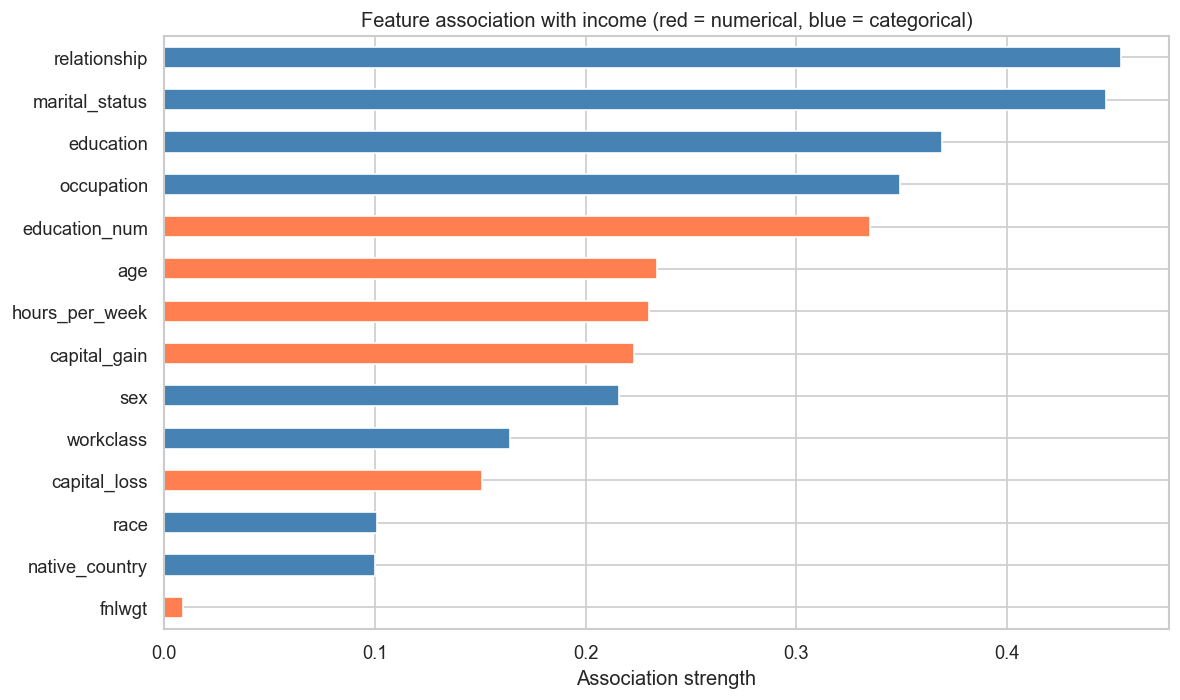

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["coral" if t == "numerical" else "steelblue" for t in combined["type"]]
combined["association"].plot(kind="barh", ax=ax, color=bar_colors)
ax.set_xlabel("Association strength")
ax.set_title("Feature association with income (red = numerical, blue = categorical)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

By combining point-biserial correlation for numerical features and Cramér's V for categorical features, a single unified ranking can be established to show how strongly each variable is linked to income.

The features most strongly tied to income are family and relationship status. Specifically, `relationship` (V = 0.454) and `marital_status` (V = 0.447) top the list, followed closely by education-related metrics like `education` (V = 0.369) and `education_num` (r = 0.335), as well as a person's `occupation` (V = 0.349).

Features like `age` (r = 0.234), `hours_per_week` (r = 0.230), `capital_gain` (r = 0.223), and `sex` (V = 0.216) also show a clear and direct relationship with income. This means that as age, work hours, or capital gains increase, a person's chance of being a high earner goes up in a predictable way, making these variables very reliable patterns for the model to learn.

The variables `workclass` (V = 0.164) and `capital_loss` (r = 0.151) show lower overall associations, while `race` (V = 0.101) and `native_country` (V = 0.100) have the weakest connection to the target variable among the features.

The population weight metric, `fnlwgt` (r = -0.009), has an association value near zero and a high p-value (0.088). Because this p-value is above the standard significance level, the null hypothesis of no association between `fnlwgt` and `income` cannot be rejected. This confirms it has no statistically meaningful connection to income and can safely be not taken into account during modeling.

### 6.6 Class-conditional feature interactions

Going beyond single-variable analysis, this subsection examines whether the income gap for one feature holds consistently across levels of another, or whether there are interaction effects. An interaction effect occurs when the impact of one variable changes depending on the value of a second variable. Rather than looking at these features in isolation, analyzing them simultaneously allows for the discovery of deeper patterns regarding how combinations of attributes relate to income levels.

To uncover these patterns, the analysis focuses on combinations of the most influential variables in the dataset, specifically evaluating how demographic factors cross paths with professional characteristics. First, the interaction between `education_num` and `sex` is explored to determine if the financial return on higher education behaves differently for men and women. Next, `occupation` and `sex` are analyzed to test if the gender gap fluctuates depending on the type of job held. Finally, the combination of `age` and `hours_per_week` is examined to see how age and weekly work hours work together to influence whether someone falls into the lower-income or higher-income bracket.

#### Income rate by `education_num` and `sex`

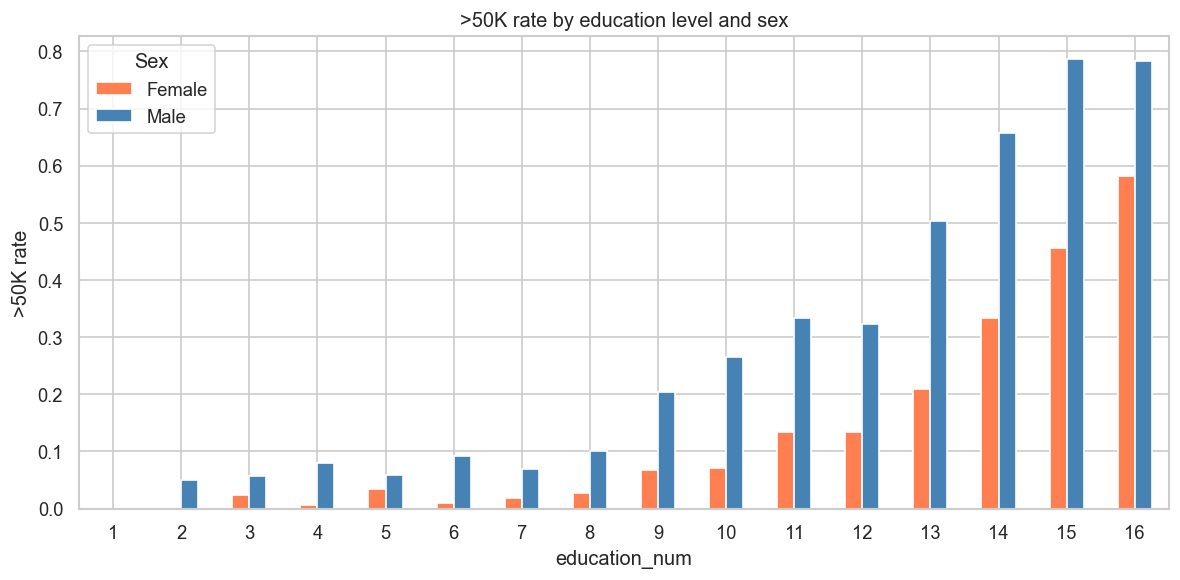

Gender gap in >50K rate by education level:
sex            Female  Male   gap
education_num                    
1               0.000 0.000 0.000
2               0.000 0.049 0.049
3               0.024 0.056 0.032
4               0.006 0.080 0.074
5               0.035 0.059 0.025
6               0.010 0.092 0.082
7               0.019 0.070 0.051
8               0.028 0.100 0.073
9               0.067 0.204 0.137
10              0.070 0.265 0.195
11              0.134 0.333 0.199
12              0.133 0.324 0.191
13              0.209 0.504 0.294
14              0.334 0.657 0.323
15              0.457 0.787 0.331
16              0.581 0.783 0.201


In [122]:
interaction = (
    df.groupby(["education_num", "sex"])[TARGET]
    .apply(lambda s: (s == ">50K").mean())
    .unstack("sex")
)

fig, ax = plt.subplots(figsize=(10, 5))
interaction.plot(kind="bar", ax=ax, color=["coral", "steelblue"])
ax.set_title(">50K rate by education level and sex")
ax.set_ylabel(">50K rate")
ax.set_xlabel("education_num")
ax.legend(title="Sex")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("Gender gap in >50K rate by education level:")
interaction["gap"] = interaction["Male"] - interaction["Female"]
print(interaction.round(3))

The interaction analysis between `education_num` and `sex` shows that while higher education increases the chances of earning a high income for both men and women, the benefits are not shared equally. At lower education levels, the income gap between genders is small simply because very few people in either group earn a high income.

As education levels rise, a clear pattern appears, and the income gap between genders becomes much larger. This gap is widest at the master's and professional degree levels, where the percentage of high-earning men increases quickly, while the percentage for women grows much slower. However, at the very highest level of education (i.e. the doctorate) the gap gets smaller again because the percentage of high-earning women increases noticeably while the male rate stays about the same.

#### Income rate by `occupation` and `sex`

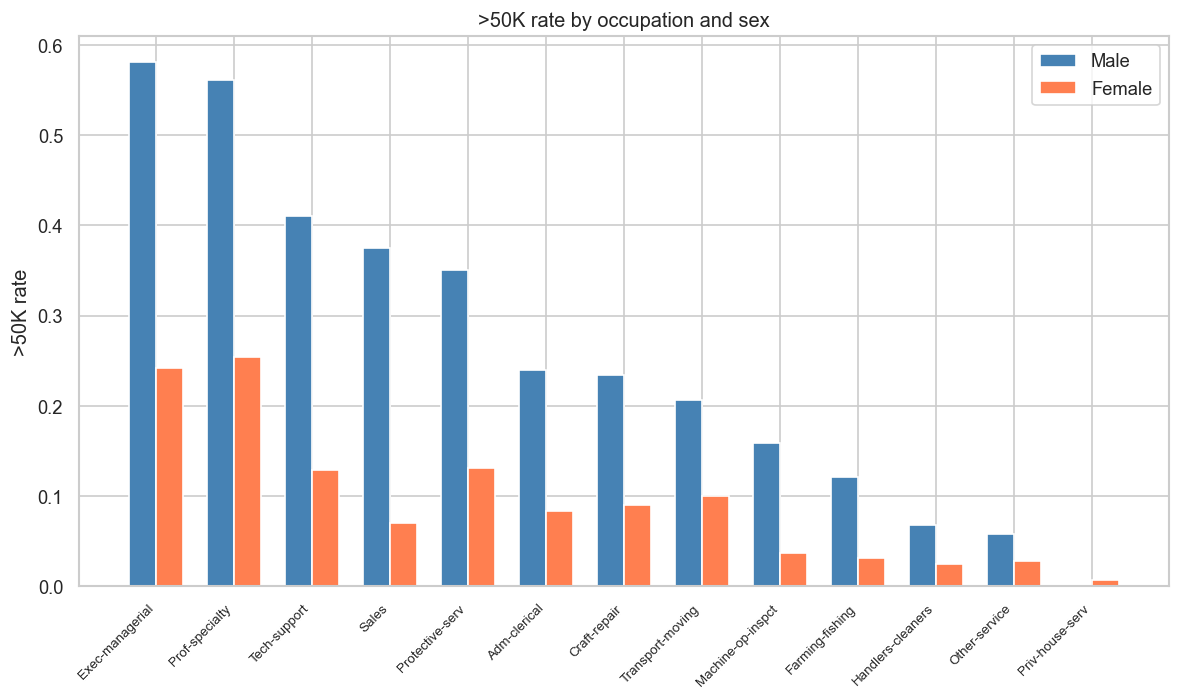

Gender gap in >50K rate by ocupation:
sex                Female  Male    gap
occupation                            
Exec-managerial     0.242 0.581  0.339
Prof-specialty      0.254 0.562  0.307
Tech-support        0.129 0.410  0.281
Sales               0.070 0.375  0.305
Protective-serv     0.132 0.351  0.219
Adm-clerical        0.084 0.239  0.156
Craft-repair        0.090 0.234  0.144
Transport-moving    0.100 0.206  0.106
Machine-op-inspct   0.036 0.158  0.122
Farming-fishing     0.031 0.122  0.091
Handlers-cleaners   0.024 0.068  0.044
Other-service       0.028 0.058  0.029
Priv-house-serv     0.007 0.000 -0.007


In [123]:
interaction2 = (
    df.groupby(["occupation", "sex"])[TARGET]
    .apply(lambda s: (s == ">50K").mean())
    .unstack("sex")
    .dropna()
    .sort_values("Male", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(interaction2))
width = 0.35
ax.bar(x - width/2, interaction2["Male"], width, label="Male", color="steelblue")
ax.bar(x + width/2, interaction2["Female"], width, label="Female", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(interaction2.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(">50K rate")
ax.set_title(">50K rate by occupation and sex")
ax.legend()
plt.tight_layout()
plt.show()

print("Gender gap in >50K rate by ocupation:")
interaction2["gap"] = interaction2["Male"] - interaction2["Female"]
print(interaction2.round(3))

The interaction analysis between occupation and sex shows that the income gap between genders changes significantly depending on the type of job. While certain professions have much higher rates of high earners overall, the difference between men and women remains present across almost all categories.

In highly paid professional and managerial roles, such as executive management and specialized professions, the percentage of high earners is the highest for both groups. However, these roles also show the largest income gaps, as the percentage of high-earning men in these positions is much higher than that of women. In contrast, for manual labor, transport, and service-oriented occupations, such as farming, cleaning, and maintenance, the high-earning rates are low for everyone, which keeps the absolute gap between men and women very small.

#### Income rate by `age` and `hours_per_week`

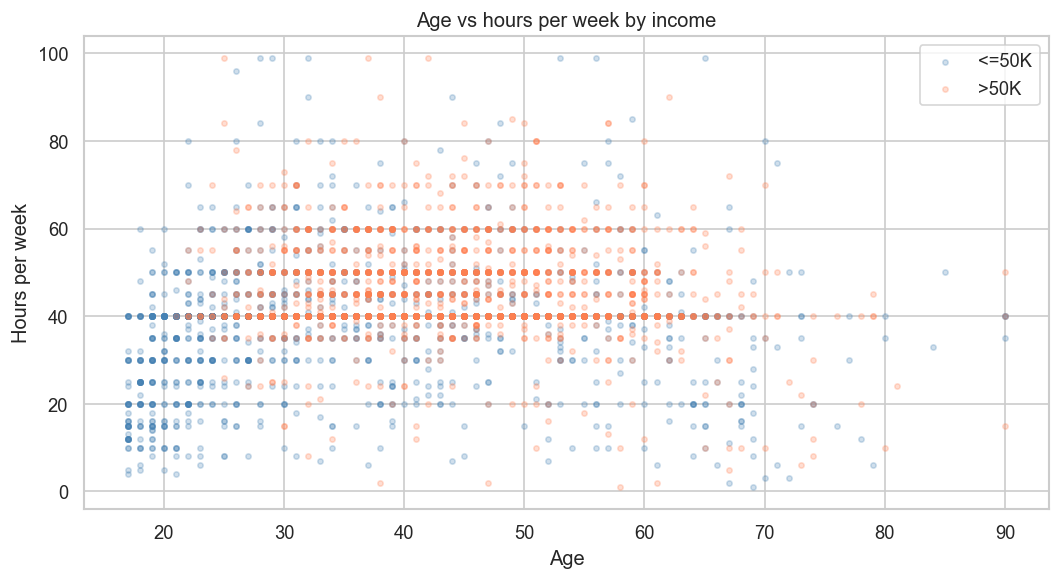

In [124]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [("<=50K", "steelblue"), (">50K", "coral")]:
    sub = df[df[TARGET] == label].sample(n=2000, random_state=SEED)
    ax.scatter(sub["age"], sub["hours_per_week"], alpha=0.25, s=10,
               label=label, color=color)
ax.set_xlabel("Age")
ax.set_ylabel("Hours per week")
ax.set_title("Age vs hours per week by income")
ax.legend()
plt.tight_layout()
plt.show()

The interaction analysis between age and hours_per_week shows distinct patterns in how a person's age and weekly work hours combine for different income groups.

Individuals in the higher-income bracket are heavily concentrated within a specific age range, typically spanning from middle adulthood to pre-retirement years, while consistently working full-time or extended weekly hours. In contrast, individuals in the lower-income bracket are much more spread out across the board. This lower-income group includes a large proportion of very young and older individuals, as well as many people who work part-time hours. This pattern indicates that working longer hours is most closely associated with higher income when it occurs during a person's main career years.

## 7. Feature relationships and redundancy

### 7.1 Numerical correlation matrix

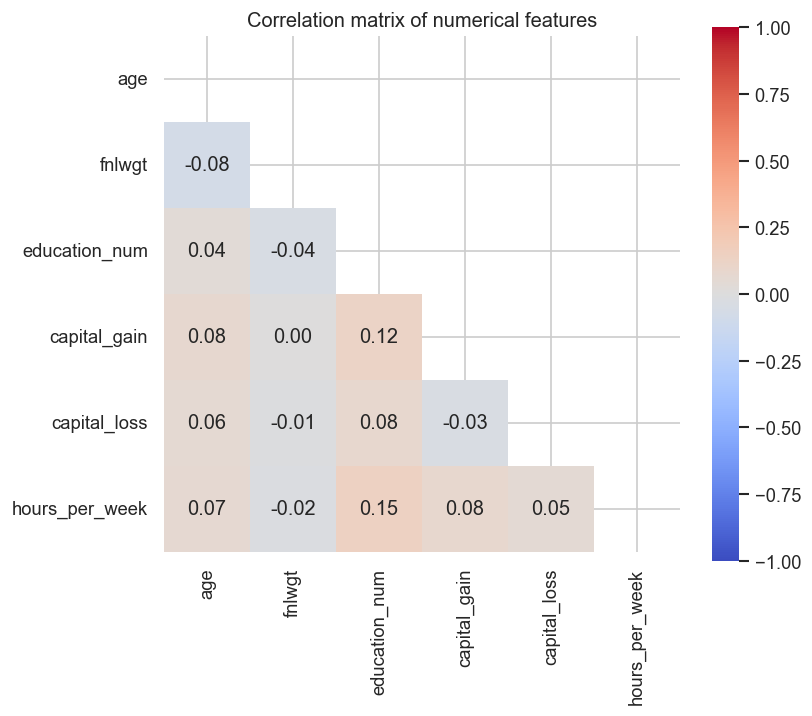

In [125]:
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()

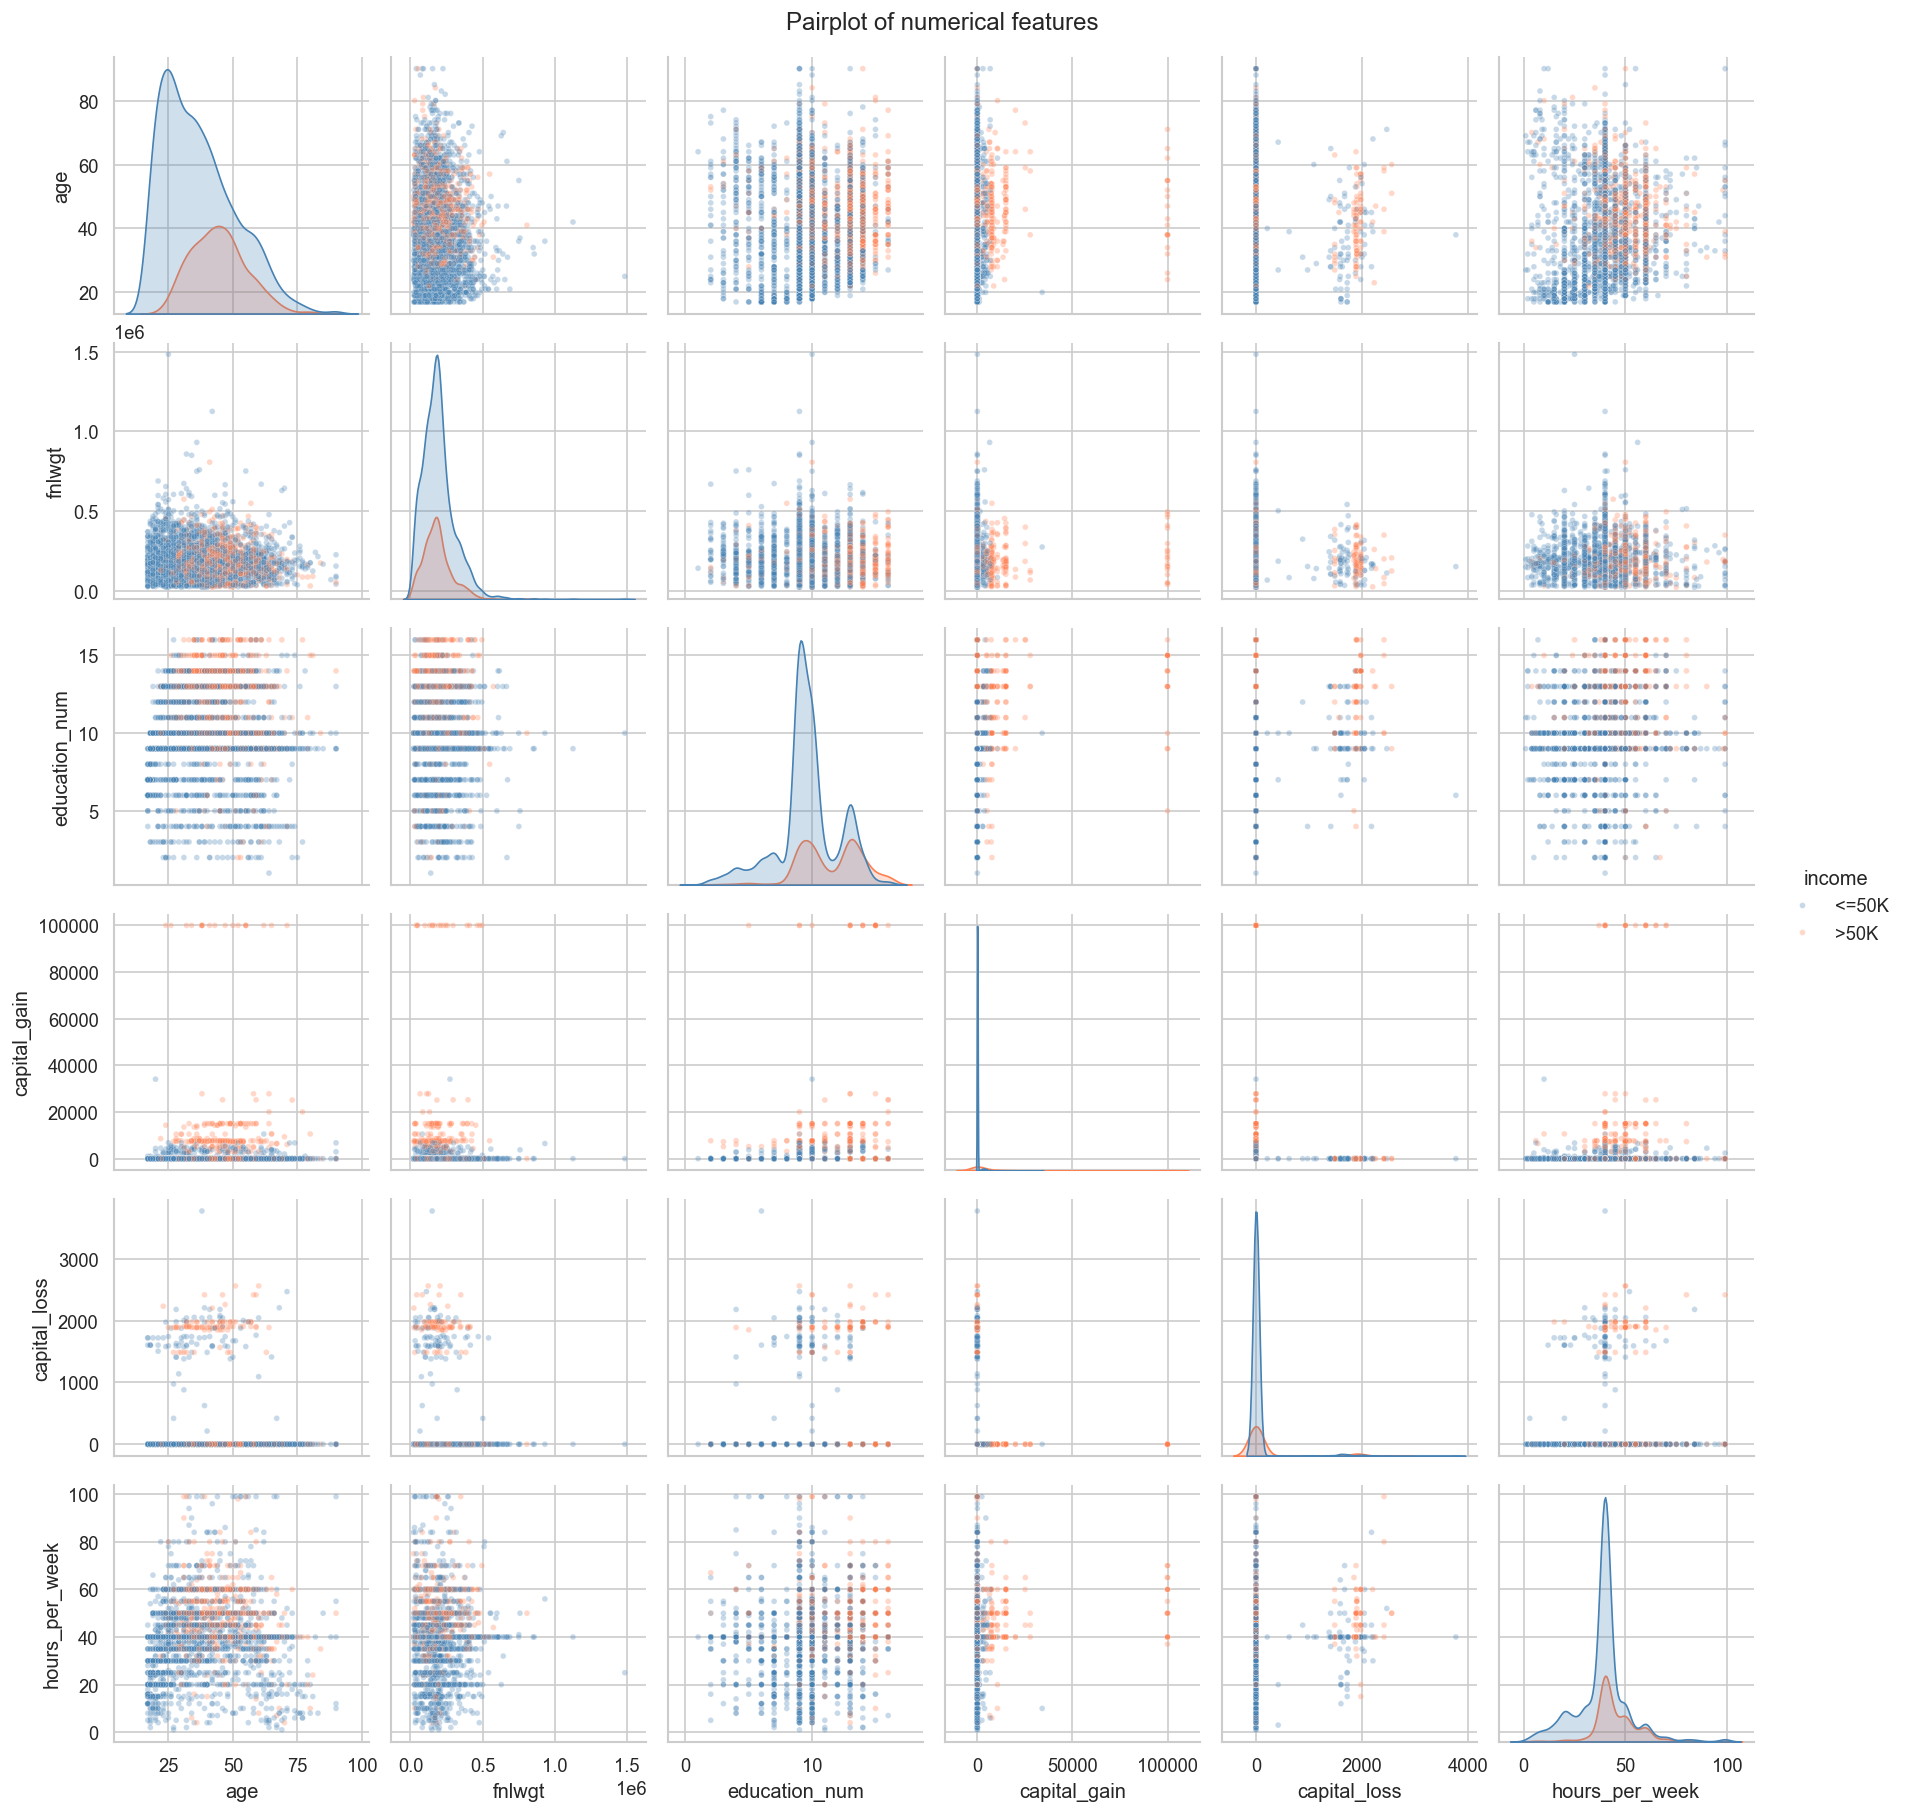

In [126]:
sample = df.sample(n=4000, random_state=SEED)[NUM_COLS + [TARGET]]
g = sns.pairplot(sample, hue=TARGET, plot_kws={"alpha": 0.3, "s": 12},
                 palette=["steelblue", "coral"])
g.figure.suptitle("Pairplot of numerical features", y=1.01)
plt.show()

An analysis of how the numerical variables relate to one another reveals that all numerical features show very low correlation with each other. Because these values are close to zero across the entire matrix, there is no concern about variables overlapping or repeating the same information, which confirms that each feature provides unique data (i.e no multicolinearity).

The highest correlation exists between `education_num` and `hours_per_week`, followed closely by the connection between `education_num` and `capital_gain`. While these links are still quite weak, they show that individuals with more years of education tend to work slightly more hours per week and see higher financial investment gains. Additionally, the variables for age, capital gains, and capital losses show slight positive relationships with one another, reflecting gradual asset accumulation over time.

In contrast, the feature fnlwgt has virtually no relationship with any other variable in the dataset, as its correlation values remain flat and close to zero across the board.

### 7.2 Categorical association matrix (Cramér's V)

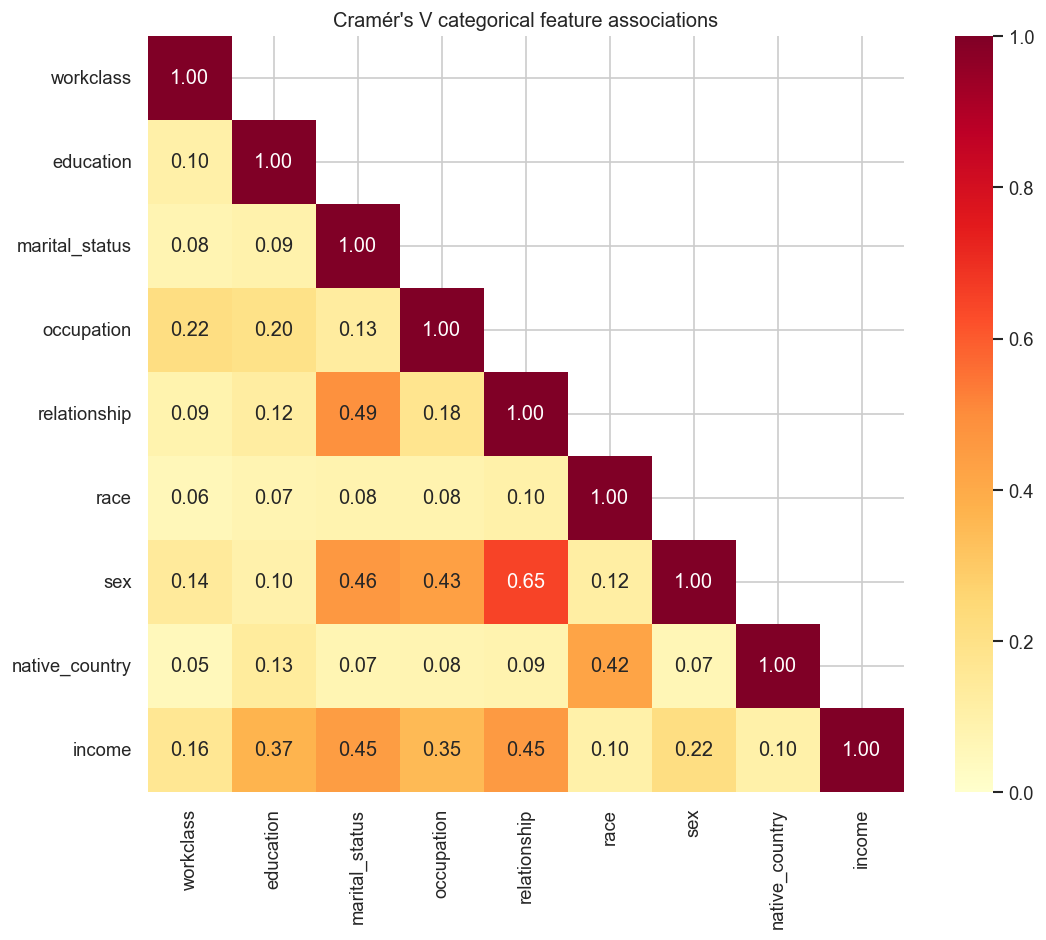

In [127]:
# Setup the dataframe for categorical combinations
cat_cols_all = CAT_COLS + [TARGET]
cv_matrix = pd.DataFrame(index=cat_cols_all, columns=cat_cols_all, dtype=float)

# Calculate Cramér's V for each pair
for c1, c2 in combinations(cat_cols_all, 2):
    valid = df[[c1, c2]].dropna()
    v = cramers_v(valid[c1], valid[c2])
    cv_matrix.loc[c1, c2] = v
    cv_matrix.loc[c2, c1] = v

# Safe pandas approach to fill the diagonal and avoid the read-only error
for col in cv_matrix.columns:
    cv_matrix.loc[col, col] = 1.0

# Plot the heatmap matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cv_matrix, dtype=bool), k=1)
sns.heatmap(cv_matrix.astype(float), mask=mask, annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1, ax=ax, square=True)

ax.set_title("Cramér's V categorical feature associations")
plt.tight_layout()

An analysis of the connections between the categorical variables using Cramér's V reveals how strongly the different categories are tied to one another.

The strongest relationship in the dataset exists between `sex` and relationship, closely followed by the connection between `marital_status` and `relationship`. There is also a very strong link between `marital_status` and `sex`. These patterns make logical sense, as an individual's role within a household is naturally tied to their marital status and gender. Additionally, a strong connection appears between `occupation` and `sex`, indicating that certain types of jobs tend to have a much higher concentration of one gender over the other. Another notable localized association is between `race` and `native_country`.

When looking at how these features relate to the target variable `income`, the strongest connections come from `relationship`, `marital_status`, `education`, and `occupation`. This indicates that personal status and career-related factors have the strongest association with whether an individual earns a high income. In contrast, variables like `race` and `native_country` show very weak links to income and operate mostly independently from the other categories in the dataset.